## Laboratorio 2 - Complejidad y búsqueda de hiperparámetros (Grupo G13)

Caso AlpesPlanck: estimación de la temperatura máxima del día siguiente.

En este laboratorio construiremos modelos de regresión polinomial y regularizada (Ridge y Lasso) sobre los datos meteorológicos de AlpesPlanck, evaluando su desempeño y estabilidad mediante validación cruzada, curvas de validación y bootstrapping.

## Preparación de los datos

Reutilizamos el proceso de limpieza y preparación construido en el Laboratorio 1, ya que el enunciado indica que se trabajará con la versión resultante de dicho proceso. A continuación se replican los pasos de limpieza sobre el conjunto de datos original.

## Importación de librerías

Importaremos las librerías necesarias para cargar, explorar, visualizar y preparar el conjunto de datos.

In [77]:
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error
import time
import warnings
from math import comb
from sklearn.base import clone
from sklearn.model_selection import GridSearchCV, KFold, cross_validate
from sklearn.preprocessing import PolynomialFeatures, MinMaxScaler
from sklearn.linear_model import Ridge, Lasso
from sklearn.metrics import root_mean_squared_error
from sklearn.exceptions import ConvergenceWarning


Cargaremos los datos y trabajaremos con una copia para conservar intacto el archivo original.

## Carga y copia de los datos

Cargaremos el conjunto de entrenamiento y crearemos una copia para realizar el análisis sin modificar directamente los datos originales.

In [78]:
Datos_temperatura = pd.read_csv("./data/Datos Lab 1.csv")
datos = Datos_temperatura.copy()
datos.head()


,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana
0,2009-01-01,999.1456,996.5000,"1,000.8700",1.3993,0.9109,0.8750,94.8000,1.7650,0.7786,...,-0.3618,-0.0223,183.5308,143.0000,"2,009.0000",1.0000,invierno,January,S,-2.1200
1,2009-01-02,999.6006,997.9300,"1,002.6500",1.5039,0.9209,86.6000,96.3000,2.7588,1.4195,...,0.4267,0.3689,40.8436,144.0000,"2,009.0000",2.0000,invierno,JULY,NE,-0.8200
2,2009-01-03,998.5486,993.0500,"1,002.4900",3.1304,76.4581,48.3900,93.9000,15.1796,1.2509,...,-0.6993,-0.5268,216.9916,144.0000,"2,009.0000",3.0000,invierno,January,SO,-0.6300
3,2009-01-04,988.5107,985.1200,992.9300,2.3223,89.4174,97.9467,NaN,4.4904,1.7204,...,-1.1268,-1.0413,222.7419,144.0000,"2,009.0000",4.0000,invierno,JANUARY,SO,-1.4400
4,2009-01-05,990.4057,NaN,997.5400,4.2315,86.2604,74.6000,93.2000,5.3922,3.8003,...,2.6275,0.2874,6.2418,NaN,"2,009.0000",5.0000,East,January,N,-10.8800


Usaremos `info()` para revisar la estructura del conjunto de datos, los tipos de las columnas y la cantidad de valores no nulos.

## Inspección inicial

Revisaremos las primeras filas y la estructura del conjunto para confirmar que los datos se cargaron correctamente.

In [79]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 2576 entries, 0 to 2575
Data columns (total 27 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   fecha              2504 non-null   str    
 1   presion_media      2501 non-null   float64
 2   presion_min        2502 non-null   float64
 3   presion_max        2512 non-null   float64
 4   presion_desv       2496 non-null   float64
 5   humedad_media      2502 non-null   float64
 6   humedad_min        2496 non-null   float64
 7   humedad_max        2490 non-null   float64
 8   humedad_desv       2515 non-null   float64
 9   viento_media       2490 non-null   float64
 10  viento_min         2485 non-null   float64
 11  viento_max         2495 non-null   float64
 12  viento_desv        2504 non-null   float64
 13  rafaga_media       2498 non-null   float64
 14  rafaga_min         2504 non-null   float64
 15  rafaga_max         2503 non-null   float64
 16  rafaga_desv        2497 non-null   

Consultaremos el diccionario de datos para comprender el significado de cada variable y orientar las decisiones de preparación.

## Diccionario de datos

Consultaremos el diccionario para comprender el significado de las variables y distinguir entre variables numéricas, categóricas y temporales.

In [80]:
diccionario = pd.read_excel('./data/Diccionario de datos.xlsx')
pd.set_option('display.max_colwidth', None)
diccionario

,variable,tipo,descripcion
0,fecha,texto,"Fecha de la observación, en formato día.mes.año."
1,presion_media,numérico,Presión atmosférica media del día (mbar).
2,presion_min,numérico,Presión atmosférica mínima del día (mbar).
3,presion_max,numérico,Presión atmosférica máxima del día (mbar).
4,presion_desv,numérico,Desviación típica de la presión durante el día (mbar).
5,humedad_media,numérico,Humedad relativa media del día (%).
6,humedad_min,numérico,Humedad relativa mínima del día (%).
7,humedad_max,numérico,Humedad relativa máxima del día (%).
8,humedad_desv,numérico,Desviación típica de la humedad relativa (%).
9,viento_media,numérico,Velocidad media del viento durante el día (m/s).


La columna `fecha` se cargó como texto. La convertiremos a un tipo de fecha para poder extraer y comparar el año, el mes y el día del año.

## Conversión de la fecha

Convertiremos `fecha` al tipo de dato fecha para utilizarla en la validación y en la creación de características temporales.

In [81]:
datos["fecha"]=pd.to_datetime(datos["fecha"], format="%Y-%m-%d")
datos["fecha"].head()

0   2009-01-01
1   2009-01-02
2   2009-01-03
3   2009-01-04
4   2009-01-05
Name: fecha, dtype: datetime64[us]

Después de comprender la estructura de los datos, revisaremos la proporción de valores faltantes en cada columna.

## Valores faltantes

Calcularemos el porcentaje de valores faltantes por columna. Este resultado orientará la estrategia de tratamiento durante la preparación de los datos.

In [82]:
((datos.isnull().sum()/datos.shape[0])*100).sort_values(ascending=False).round(3)

temp_max_manana     3.6880
viento_min          3.5330
estacion_anio       3.4160
mes                 3.4160
anio                3.3390
humedad_max         3.3390
viento_media        3.3390
viento_max          3.1440
humedad_min         3.1060
viento_norte        3.1060
presion_desv        3.1060
rafaga_desv         3.0670
direccion_viento    3.0670
rafaga_media        3.0280
registros_del_dia   2.9890
presion_media       2.9110
presion_min         2.8730
humedad_media       2.8730
rafaga_max          2.8340
rafaga_min          2.7950
viento_desv         2.7950
fecha               2.7950
sector_viento       2.7560
dia_del_anio        2.6400
presion_max         2.4840
viento_este         2.4840
humedad_desv        2.3680
dtype: float64

Revisaremos las estadísticas descriptivas para conocer los rangos, valores centrales y dispersión de las variables numéricas.

## Estadísticas descriptivas

Analizaremos las principales medidas estadísticas de las variables numéricas para identificar su comportamiento y posibles valores atípicos.

In [83]:
datos.describe()

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,rafaga_min,rafaga_max,rafaga_desv,viento_norte,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,temp_max_manana
count,2504,"2,501.0000","2,502.0000","2,512.0000","2,496.0000","2,502.0000","2,496.0000","2,490.0000","2,515.0000","2,490.0000",...,"2,504.0000","2,503.0000","2,497.0000","2,496.0000","2,512.0000","2,497.0000","2,499.0000","2,490.0000","2,508.0000","2,481.0000"
mean,2012-06-29 14:19:10.159744,"1,010.4943",986.6844,991.7042,1.7520,52.4136,45.0941,90.2366,10.6068,3.8141,...,-2.6393,6.9461,-5.7633,-1.1285,-0.4102,172.1046,144.0908,"2,011.9956",182.6910,13.8633
min,2009-01-01 00:00:00,948.9960,913.6000,951.9400,0.2269,0.0047,0.2377,27.0200,0.0000,0.0000,...,"-9,999.0000",0.0000,-232.2600,"-1,250.4633",-3.7185,0.0000,90.0000,"2,009.0000",1.0000,-15.2300
25%,2010-09-22 18:00:00,984.2878,981.3713,987.0700,0.8991,0.8691,1.0118,88.0250,6.0821,1.6553,...,0.4400,4.8032,1.0021,-1.6406,-1.2365,91.3035,144.0000,"2,010.0000",91.0000,7.3100
50%,2012-07-04 12:00:00,989.4528,987.0700,991.9350,1.4446,68.5581,49.6700,93.3000,10.1998,2.4634,...,0.6600,6.6900,1.4611,-0.5643,-0.3560,199.5685,144.0000,"2,012.0000",182.5000,14.3100
75%,2014-03-30 06:00:00,994.4690,992.5675,996.7825,2.2548,80.5626,67.6650,96.6000,14.7222,4.8805,...,1.1200,8.8500,2.0088,0.2415,0.3163,227.1017,144.0000,"2,014.0000",274.2500,20.4600
max,2015-12-31 00:00:00,"9,939.9180","1,012.3202","1,013.9400",12.3975,100.0000,103.3114,100.0000,26.3416,24.7536,...,19.8959,23.5000,"3,471.0278",4.8099,4.7139,359.7967,287.0000,"2,015.0000",366.0000,63.0500
std,NaN,435.3345,8.9271,7.7269,1.2159,35.9754,30.1962,10.6472,5.4813,3.3074,...,199.8617,3.2374,75.2581,25.0651,1.1472,86.1023,4.1074,1.9997,105.5295,9.2962


Después de revisar las estadísticas, verificaremos la existencia de registros duplicados.

## Duplicados completos

Verificaremos si existen filas completamente duplicadas. Estos registros podrían repetir exactamente la misma observación y afectar el análisis.

In [84]:
print(f"Existen {datos.duplicated(keep = False).sum()} filas duplicadas en los datos.")

Existen 8 filas duplicadas en los datos.


## Revisión de fechas repetidas

Comprobaremos cuántas filas comparten la misma fecha. Una fecha repetida no implica necesariamente que la fila completa sea un duplicado.

In [85]:
print(f"Existen {datos['fecha'].duplicated(keep = False).sum()} filas con fecha duplicada.")

Existen 108 filas con fecha duplicada.


Revisaremos si existen fechas nulas, ya que una fecha faltante impide validar las características temporales del registro.

## Fechas nulas

Contaremos las fechas faltantes porque una fecha nula impide determinar el año, el mes y el día del año asociados al registro.

In [86]:
datos["fecha"].isnull().sum()

np.int64(72)

## Eliminación de fechas faltantes

Eliminaremos las filas con fecha faltante, porque no es posible reconstruir de forma confiable las características temporales de esos registros.

In [87]:
datos= datos.dropna(subset=['fecha'])
datos["fecha"].isnull().sum()

np.int64(0)

Después de revisar los duplicados completos, inspeccionaremos las filas que tienen fechas repetidas.

## Inspección de fechas repetidas

Mostraremos los registros con fechas repetidas y el número de apariciones de cada fecha. Esto permite distinguir duplicados reales de observaciones diferentes del mismo día.

In [88]:
dup_table = (
    datos[datos['fecha'].duplicated(keep=False)]
    .copy()
    .assign(Repeticiones=datos.groupby('fecha')['fecha'].transform('size'))
    .sort_values(['Repeticiones', 'fecha'], ascending=[False, True])
)
dup_table

,fecha,presion_media,presion_min,presion_max,presion_desv,humedad_media,humedad_min,humedad_max,humedad_desv,viento_media,...,viento_este,direccion_viento,registros_del_dia,anio,dia_del_anio,estacion_anio,mes,sector_viento,temp_max_manana,Repeticiones
21,2009-01-22,"9,784.1150",971.4800,983.5400,3.9853,86.7311,69.1100,97.6000,9.7926,10.0969,...,-0.1899,183.9897,144.0000,"2,009.0000",22.0000,verano,octubre,S,5.7700,2
2563,2009-01-22,"9,784.1150",971.4800,983.5400,3.9853,86.7311,69.1100,97.6000,9.7926,10.0969,...,-0.1899,183.9897,144.0000,"2,009.0000",22.0000,verano,octubre,S,5.7700,2
63,2009-03-05,959.8607,958.6700,962.5400,0.8964,94.2944,86.0000,97.8000,2.8296,1.2908,...,0.1826,9.3166,144.0000,"2,009.0000",64.0000,primavera,July,N,5.3700,2
2574,2009-03-05,959.8607,958.6700,962.5400,0.8964,NaN,86.0000,97.8000,2.8296,1.2908,...,0.1826,9.3166,144.0000,"2,009.0000",64.0000,primavera,July,N,5.9560,2
121,2009-05-02,998.1189,995.9900,999.4100,0.9205,77.5000,51.0900,99.6000,18.9020,1.8444,...,0.4668,23.7431,144.0000,NaN,122.0000,primavera,october,NaN,20.8900,2
2568,2009-05-02,998.8552,995.9900,999.4100,0.9205,77.5000,51.0900,99.6000,18.9020,1.8444,...,0.4668,23.7431,144.0000,"2,009.0000",122.0000,primavera,october,NE,20.8900,2
341,2009-12-08,983.8490,979.4500,991.4000,3.7836,0.8780,0.8010,96.8000,5.9641,4.5349,...,-0.8314,233.2095,144.0000,"2,009.0000",342.0000,verano,Enero,SO,7.1200,2
2575,2009-12-08,983.8490,979.4500,991.4000,3.7836,1.0213,0.8010,96.8000,5.9641,4.5349,...,NaN,233.2095,144.0000,"2,009.0000",342.0000,verano,Enero,SO,7.1200,2
590,2010-08-14,990.4828,989.2200,991.2900,0.4346,84.3864,65.1200,95.7000,9.4681,1.7086,...,0.6511,39.5952,144.0000,"2,010.0000",226.0000,verano,August,NE,19.5000,2
2566,2010-08-14,991.2727,989.2200,991.2900,0.4346,84.3864,65.1200,95.7000,9.4681,1.7086,...,0.6511,39.5952,144.0000,"2,010.0000",226.0000,verano,August,NE,19.5000,2


## Ajustes de normalizacion de la Humedad

Aca ajustaremos los valores de la humedad ya que algunos estan entre 0-1 y otros enter 1-100, para esto dejaremos todos entre 0-1 como fraccion y proporcion de porcentaje


In [89]:
for col in ["humedad_media", "humedad_max", "humedad_min"]:
    datos[col] = datos[col].where(datos[col] <= 1, datos[col] / 100)
    datos[col] = datos[col].clip(upper=1)


## Ajuste de escala de presion

Hay algunos valores de los datos de presión que están en una escala incorrecta (multiplicados por 10, ej. 9784 en vez de 978.4). En vez de descartarlos, corregimos la escala dividiendo entre 10 cuando el valor resultante cae en un rango físicamente válido (900-1100 hPa); solo los valores que sigan siendo inválidos después de este ajuste se marcan como faltantes.

In [90]:
for col in ["presion_media", "presion_max", "presion_min"]:
    reescalado = datos[col] / 10
    fuera_de_rango = (datos[col] < 900) | (datos[col] > 1100)
    recuperable = fuera_de_rango & reescalado.between(900, 1100)

    print(f"{col}: {fuera_de_rango.sum()} valores fuera de rango, "
          f"{recuperable.sum()} recuperados al corregir la escala (x10).")

    datos[col] = np.where(recuperable, reescalado, datos[col])
    datos[col] = np.where((datos[col] < 900) | (datos[col] > 1100), np.nan, datos[col])

presion_media: 6 valores fuera de rango, 6 recuperados al corregir la escala (x10).
presion_max: 0 valores fuera de rango, 0 recuperados al corregir la escala (x10).
presion_min: 0 valores fuera de rango, 0 recuperados al corregir la escala (x10).


## Depuración de fechas repetidas

Después de inspeccionar los registros repetidos, conservaremos una sola observación por fecha, asumiendo que el conjunto debe contener una fila diaria.



In [91]:
datos = datos.drop_duplicates(subset=['fecha'], keep='first')

duplicados_restantes = datos['fecha'].duplicated(keep=False).sum()
print(f"Existen {duplicados_restantes} fechas duplicadas después de la limpieza.")

Existen 0 fechas duplicadas después de la limpieza.


## Controles generales de calidad

Realizaremos verificaciones de tipos de datos, valores faltantes, duplicados y rango temporal después de la limpieza inicial.

In [92]:
print("Tipos de datos:")
print(datos.dtypes)
print()

faltantes = datos.isna().sum().sort_values(ascending=False)
print("Valores faltantes por columna (solo columnas con al menos 1 faltante):")
print(faltantes[faltantes > 0])
print()

print(f"Filas completamente duplicadas: {datos.duplicated().sum()}")
print(f"Fechas repetidas: {datos['fecha'].duplicated().sum()}")
print(f"Rango de fechas: {datos['fecha'].min().date()} a {datos['fecha'].max().date()}")

Tipos de datos:
fecha                datetime64[us]
presion_media               float64
presion_min                 float64
presion_max                 float64
presion_desv                float64
humedad_media               float64
humedad_min                 float64
humedad_max                 float64
humedad_desv                float64
viento_media                float64
viento_min                  float64
viento_max                  float64
viento_desv                 float64
rafaga_media                float64
rafaga_min                  float64
rafaga_max                  float64
rafaga_desv                 float64
viento_norte                float64
viento_este                 float64
direccion_viento            float64
registros_del_dia           float64
anio                        float64
dia_del_anio                float64
estacion_anio                   str
mes                             str
sector_viento                   str
temp_max_manana             float64
dtype: objec

## Detección de valores atípicos

Usaremos diagramas de caja para identificar valores extremos en las variables numéricas. Posteriormente con los IQR vamos a quitar los datos anomalos para tener mejor resultado y presicion


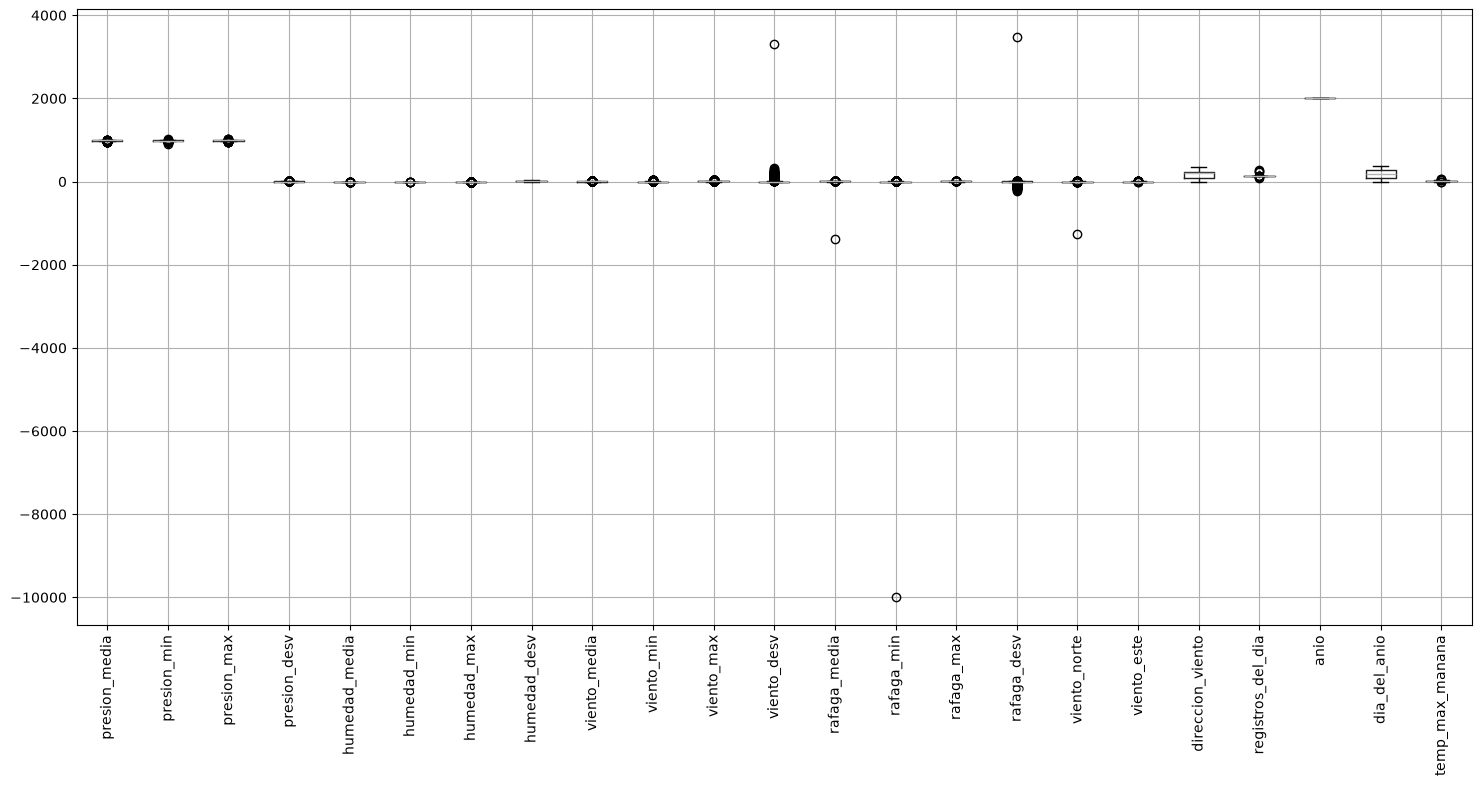

In [93]:
datos.select_dtypes(include="number").boxplot(
    figsize=(18, 8),
    rot=90
)
plt.show()

Aca vemos que hay varios valores outliners que nos dañan la calidad de los datos, para esto los ajustaremos con los IQR para tener intervalos de confianza logicos que nos permitiran distingir y tener mejores datos y resultados, ademas se compararan los resultados en varios boxplot para ver que todo haya funcionado bien

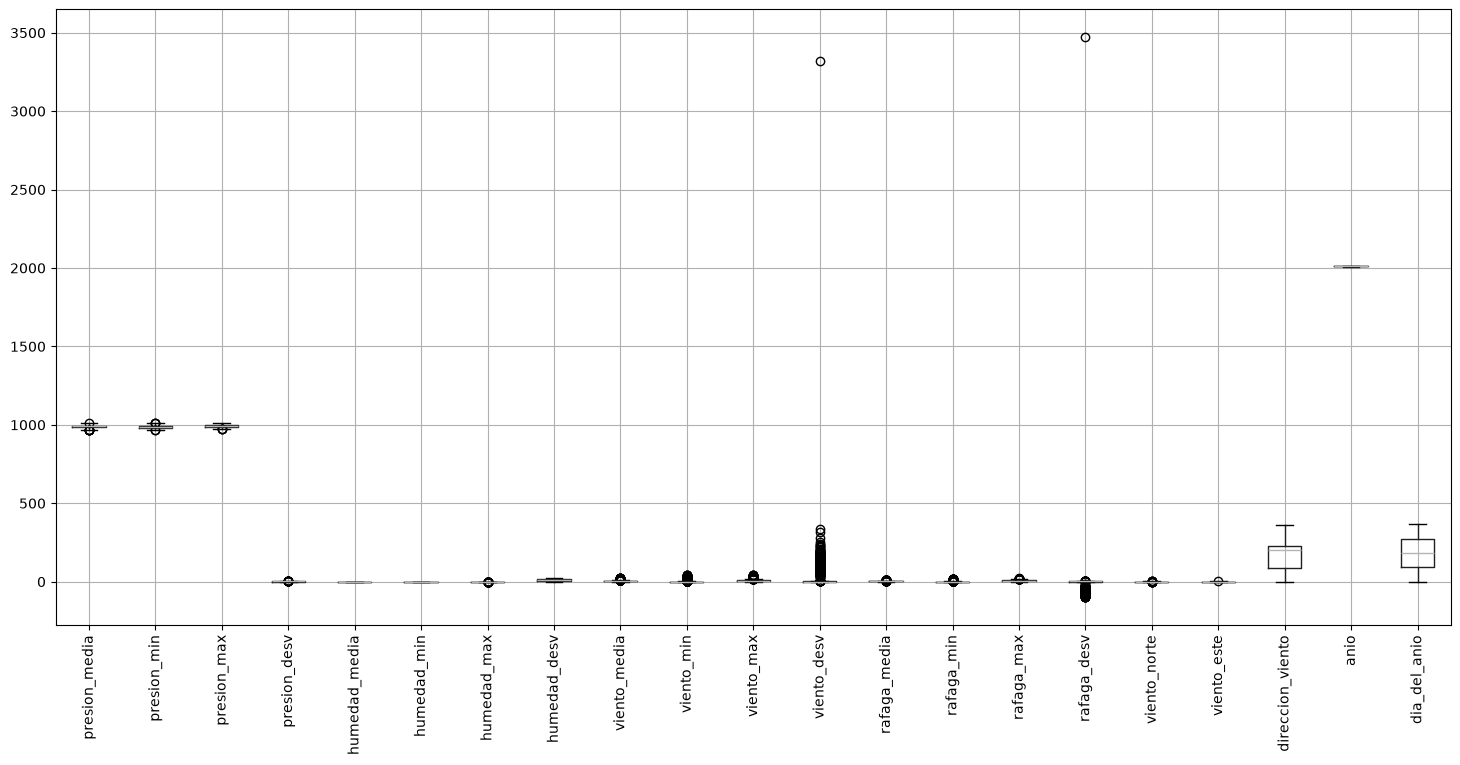

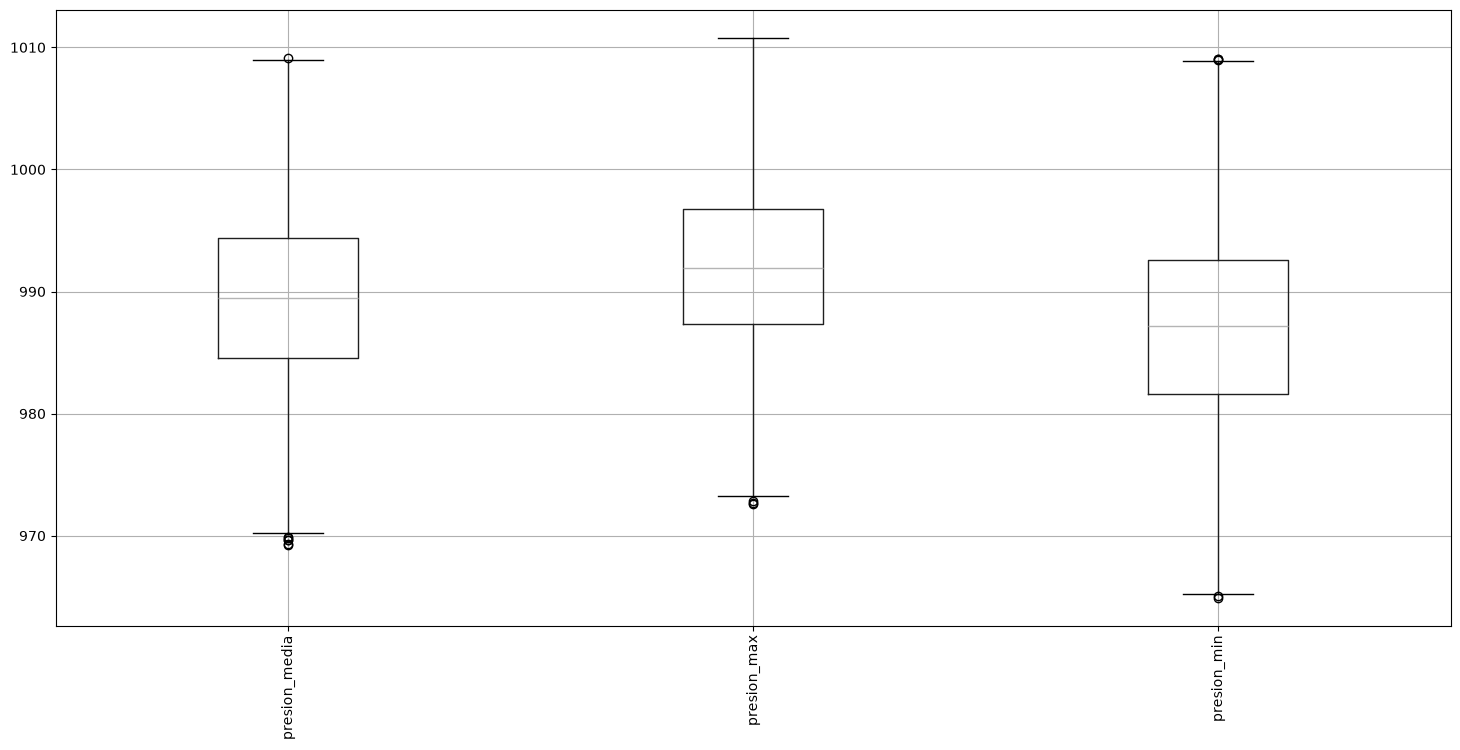

In [94]:
datos_numericos = (
    datos.select_dtypes(include="number")
    .drop(columns=["temp_max_manana", "registros_del_dia"], errors="ignore")
)

cols_viento = [
    "viento_max", "viento_min", "viento_media", "viento_desv",
    "rafaga_media", "rafaga_max", "rafaga_min", "rafaga_desv"
]

for col in cols_viento:
    datos[col] = pd.to_numeric(datos[col], errors="coerce")
    datos.loc[datos[col] <= -100, col] = np.nan

datos_numericos[cols_viento] = datos[cols_viento]

for column in datos_numericos.columns:
    if column in cols_viento:
        continue

    q1 = datos_numericos[column].quantile(0.25)
    q3 = datos_numericos[column].quantile(0.75)
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    datos_numericos[column] = datos_numericos[column].apply(
        lambda x: x if lower_bound <= x <= upper_bound else None
    )


datos_numericos.select_dtypes(include="number").boxplot(
    figsize=(18, 8),
    rot=90
)
plt.show()

datos[datos_numericos.columns] = datos_numericos


datos.boxplot(
    column=["presion_media", "presion_max", "presion_min"],
    figsize=(18, 8),
    rot=90
)
plt.show()


Las columnas de viento y ráfaga (`viento_*`, `rafaga_*`) se excluyen deliberadamente del recorte por IQR: son variables con distribuciones naturalmente sesgadas y colas largas (ráfagas fuertes ocasionales son eventos reales, no errores), por lo que aplicar el mismo criterio que a las demás variables numéricas recortaría información climática válida. En su lugar, para estas columnas solo se tratan como faltantes los valores físicamente imposibles (`<= -100`, ver más arriba).

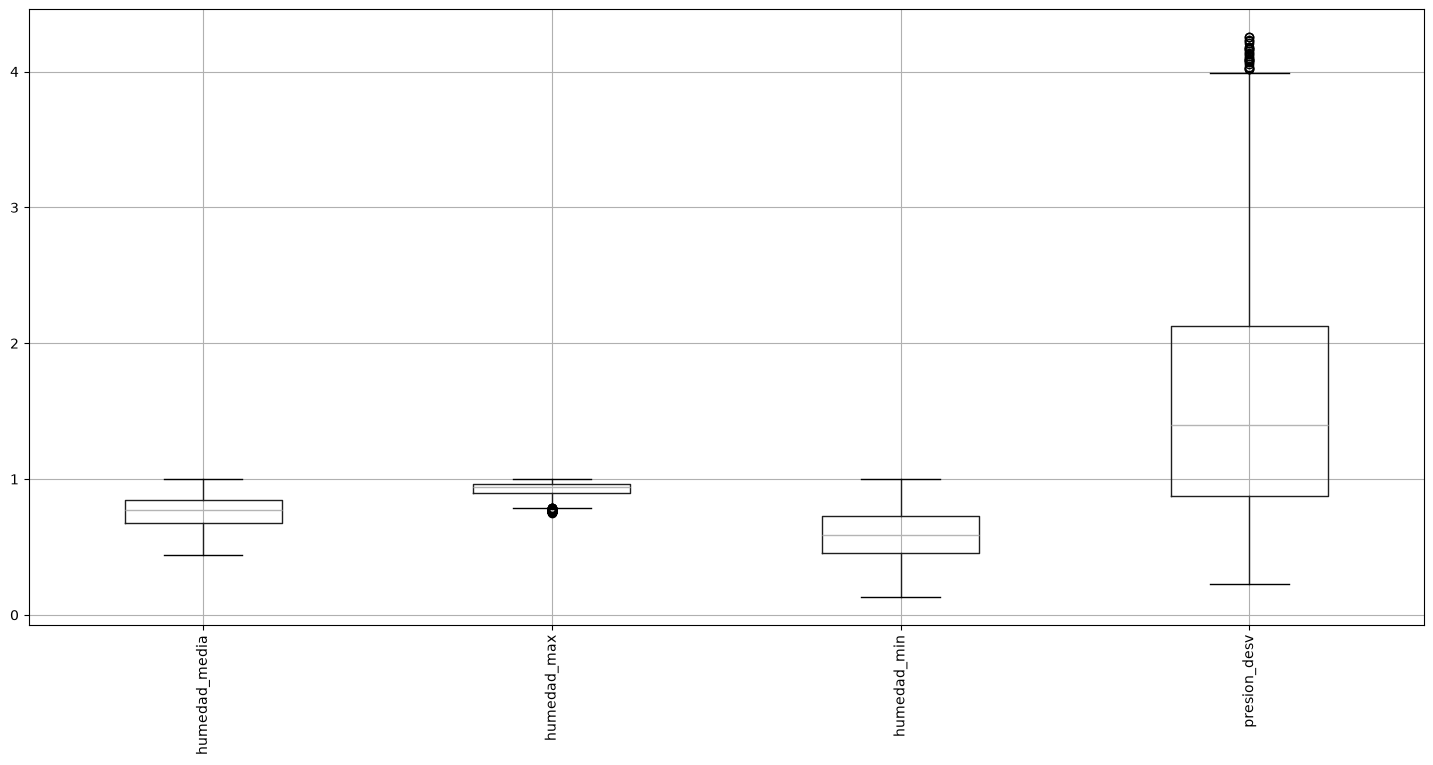

In [95]:
datos.boxplot(
    column=["humedad_media", "humedad_max", "humedad_min","presion_desv"],
    figsize=(18, 8),
    rot=90
)

plt.show()

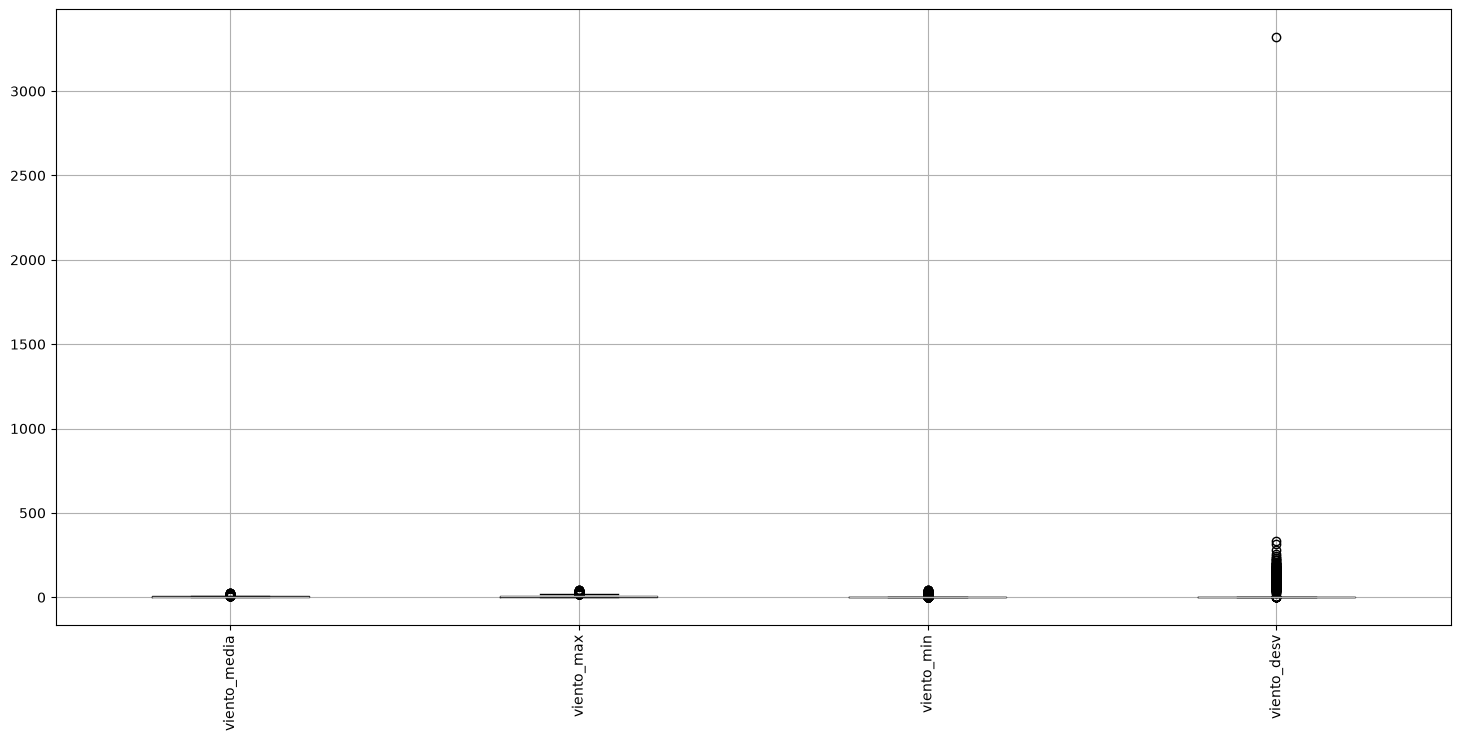

In [96]:
datos.boxplot(
    column=["viento_media", "viento_max", "viento_min","viento_desv"],
    figsize=(18, 8),
    rot=90
)

plt.show()

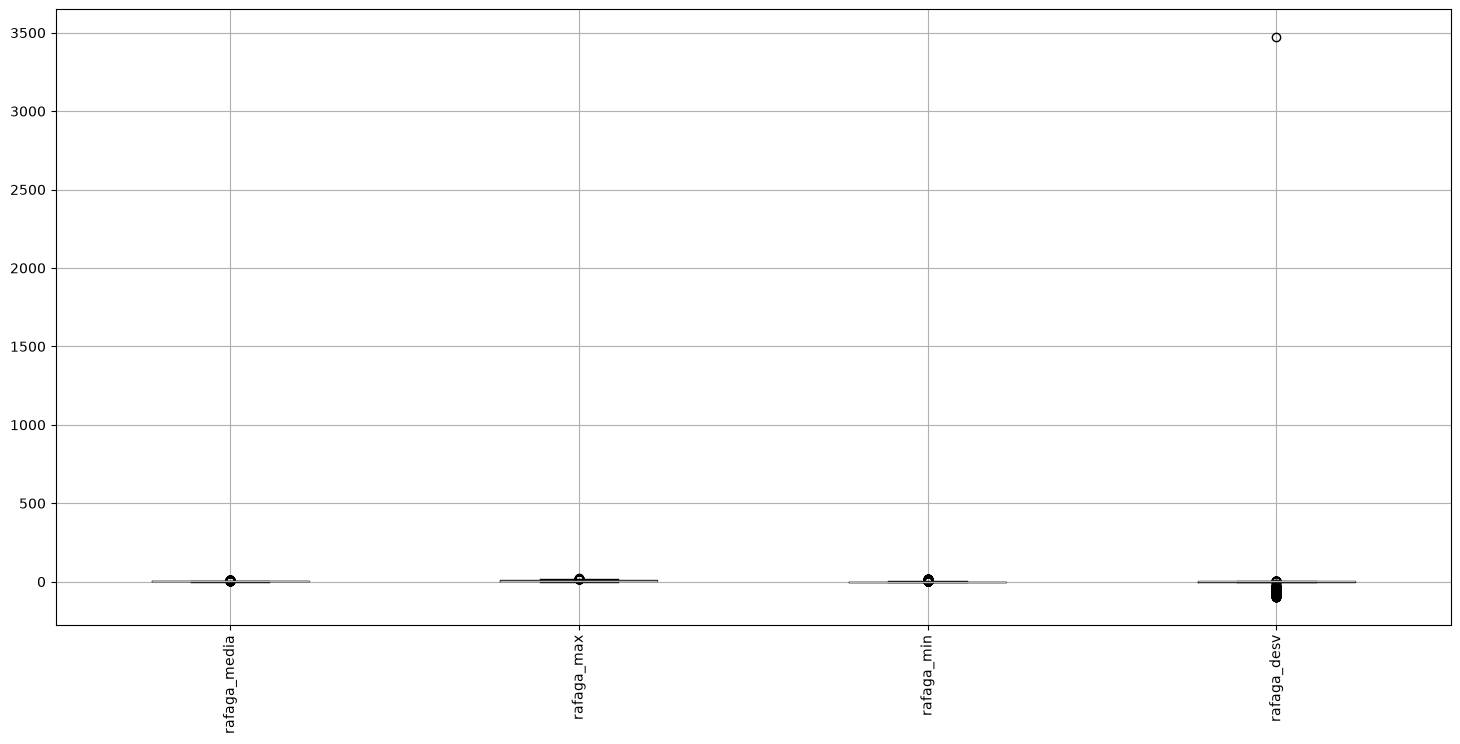

In [97]:
datos.boxplot(
    column=["rafaga_media", "rafaga_max", "rafaga_min","rafaga_desv"],
    figsize=(18, 8),
    rot=90
)

plt.show()

In [98]:
datos.select_dtypes(include="object").nunique()
for columna in datos.select_dtypes(include="object"):
    print(f"\n{columna}:")
    print(datos[columna].value_counts(dropna=False))


estacion_anio:
estacion_anio
primavera               505
invierno                504
otono                   479
verano                  459
NaN                      87
Inverano                 66
Estacion_Desconocida     62
VERANO_INVIERNO          58
East                     48
VERANO                   18
berano                   17
autumn                   17
primaveraa               15
winter                   15
fall                     14
verno                    13
otoño                    11
Primavera                10
Otoño                    10
invierno                  9
Verano                    9
PRIMAVERA                 9
invernio                  9
Invierno                  9
INVIERNO                  8
OTONO                     8
primav                    6
spring                    6
summer                    5
Name: count, dtype: int64

mes:
mes
May        122
July       120
August     119
January    116
March      116
          ... 
junio       16
JANUARY     14
ap

C:\Users\sebas\AppData\Local\Temp\ipykernel_31788\583941038.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  datos.select_dtypes(include="object").nunique()
C:\Users\sebas\AppData\Local\Temp\ipykernel_31788\583941038.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration

Al revisar las variables temporales y categóricas, identificamos posibles inconsistencias en los años, meses, días, estaciones y sectores del viento. Las corregiremos usando la fecha y las variables relacionadas.

In [99]:
datos["anio"] = datos["fecha"].dt.year
datos["dia_del_anio"] = datos["fecha"].dt.dayofyear

In [100]:
datos["mes"].unique()

<StringArray>
[   'January',       'JULY',    'JANUARY',        'May',      'Enero',
          nan,       'JUNE',        'Sep',      'April',  'SEPTEMBER',
  'noviembre',    'octubre',       'Sept',   'november',      'april',
      'julio',   'February',      'APRIL',        'Aug',    'febrero',
 'septiembre',        'Mar',        'Nov',      'MARCH',   'february',
   'November',        'may',       'july',     'august',  'september',
       'July',      'March',    'October',      'junio',    'october',
      'march',      'marzo',  'September',        'Oct',   'DECEMBER',
        'Jan',      'enero',   'NOVEMBER',   'december',        'Jul',
    'OCTOBER',        'Jun',  'diciembre',     'AUGUST',       'June',
    'january',       'june',        'Feb',     'August',   'December',
     'agosto',        'Apr',       'mayo',      'abril',   'FEBRUARY',
        'MAY',        'Dec']
Length: 62, dtype: str

In [101]:
meses_es = {
    "January": "enero", "February": "febrero", "March": "marzo", "April": "abril",
    "May": "mayo", "June": "junio", "July": "julio", "August": "agosto",
    "September": "septiembre", "October": "octubre", "November": "noviembre", "December": "diciembre"
}
datos["mes"] = datos["fecha"].dt.month_name().map(meses_es)
datos["mes"].unique()

<StringArray>
[     'enero',    'febrero',      'marzo',      'abril',       'mayo',
      'junio',      'julio',     'agosto', 'septiembre',    'octubre',
  'noviembre',  'diciembre']
Length: 12, dtype: str


Aca se va a poner los dias como variables ciclicas con funciones de seno y coseno ya que asi se nota mas la correlacion que esta informacion tiene con la variable objetivo que simplemente el dato a secas como un numero de dia, esto ya que al volverlo ciclico se ve las la correlacion.



In [102]:
datos["dia_del_anio"] = datos["fecha"].dt.dayofyear

datos["dia_sin"] = np.sin(2 * np.pi * datos["dia_del_anio"] / 365.25)
datos["dia_cos"] = np.cos(2 * np.pi * datos["dia_del_anio"] / 365.25)

## Tratamiento de valores faltantes

Revisaremos nuevamente los valores faltantes y definiremos una estrategia según el tipo y el significado de cada variable.

In [103]:
datos.isna().sum().sort_values(ascending=False)

humedad_max          236
presion_desv         173
rafaga_desv          159
viento_norte         125
presion_media        114
presion_min          111
humedad_media        100
presion_max           98
temp_max_manana       93
viento_min            88
estacion_anio         87
viento_media          82
viento_max            79
viento_este           78
humedad_min           78
direccion_viento      77
registros_del_dia     77
rafaga_media          77
rafaga_min            71
viento_desv           69
sector_viento         69
rafaga_max            68
humedad_desv          59
fecha                  0
anio                   0
mes                    0
dia_del_anio           0
dia_sin                0
dia_cos                0
dtype: int64

Como `temp_max_manana` es la variable objetivo, eliminaremos los registros que no tienen esta etiqueta, ya que no pueden utilizarse para entrenar el modelo.

In [104]:
datos=datos.dropna(subset=["temp_max_manana"])
datos["temp_max_manana"].isnull().sum()

np.int64(0)

Para las variables numéricas predictoras con valores faltantes, utilizaremos la mediana. Esta medida es menos sensible a los valores atípicos que el promedio.

In [105]:
columnas_numericas = datos.select_dtypes(include="number").columns.drop(
    ["temp_max_manana", "direccion_viento"],
    errors="ignore"
)

medianas_entrenamiento = datos[columnas_numericas].median()
datos[columnas_numericas] = datos[columnas_numericas].fillna(medianas_entrenamiento)

Calcularemos los valores faltantes de `direccion_viento` a partir de las componentes `viento_este` y `viento_norte`, que ya fueron completadas.

In [106]:
direccion_calculada = (
    np.degrees(
        np.arctan2(datos["viento_este"], datos["viento_norte"])
    ) % 360
)

datos["direccion_viento"] = datos["direccion_viento"].fillna(
    direccion_calculada
)

Revisaremos los valores de `estacion_anio` y completaremos los faltantes usando la fecha como fuente de información.

In [107]:
datos["estacion_anio"].unique()

<StringArray>
[            'invierno',                 'East',                    nan,
 'Estacion_Desconocida',               'verano',             'Inverano',
            'invierno ',             'INVIERNO',      'VERANO_INVIERNO',
               'Verano',            'primavera',           'primaveraa',
            'PRIMAVERA',               'berano',               'VERANO',
                'verno',                'otono',               'otoño ',
                 'fall',               'autumn',                'OTONO',
               'winter',             'invernio',            'Primavera',
               'primav',               'spring',                'Otoño',
             'Invierno',               'summer']
Length: 29, dtype: str

In [108]:
datos["estacion_anio"] = datos["fecha"].dt.month.map({
    1: "invierno",
    2: "invierno",
    3: "primavera",
    4: "primavera",
    5: "primavera",
    6: "verano",
    7: "verano",
    8: "verano",
    9: "otoño",
    10: "otoño",
    11: "otoño", 
    12: "invierno"
})

datos["estacion_anio"].unique()

<StringArray>
['invierno', 'primavera', 'verano', 'otoño']
Length: 4, dtype: str

In [109]:
estacion_calculada = datos["fecha"].dt.month.map({
    1: "invierno",
    2: "invierno",
    3: "primavera",
    4: "primavera",
    5: "primavera",
    6: "verano",
    7: "verano",
    8: "verano",
    9: "otoño",
    10: "otoño",
    11: "otoño",
    12: "invierno"
})

datos["estacion_anio"] = datos["estacion_anio"].fillna(estacion_calculada)

Completaremos los valores faltantes de `sector_viento` usando `direccion_viento` como referencia.

In [110]:
sectores = np.array(["N", "NE", "E", "SE", "S", "SO", "O", "NO"])

indice_sector = (
    ((datos["direccion_viento"] + 22.5) // 45) % 8
).astype(int)

sector_calculado = pd.Series(
    sectores[indice_sector],
    index=datos.index
)

datos["sector_viento"] = datos["sector_viento"].fillna(
    sector_calculado
)

## Verificación de valores faltantes

Confirmaremos que no queden valores nulos después de aplicar las estrategias de limpieza.

In [111]:
datos.isna().sum().sort_values(ascending=False)

fecha                0
presion_media        0
presion_min          0
presion_max          0
presion_desv         0
humedad_media        0
humedad_min          0
humedad_max          0
humedad_desv         0
viento_media         0
viento_min           0
viento_max           0
viento_desv          0
rafaga_media         0
rafaga_min           0
rafaga_max           0
rafaga_desv          0
viento_norte         0
viento_este          0
direccion_viento     0
registros_del_dia    0
anio                 0
dia_del_anio         0
estacion_anio        0
mes                  0
sector_viento        0
temp_max_manana      0
dia_sin              0
dia_cos              0
dtype: int64

## Verificación de sectores del viento

Revisaremos las categorías resultantes para confirmar que los sectores estén unificados.

In [112]:
datos["sector_viento"].unique()

<StringArray>
[        'S',        'NE',        'SO',         'N',     'South',   'Sureste',
  'Suroeste',       'Sur',         'O',        'NO',     'North',        'so',
     'Oeste',         'o',         'E', 'NORTHEAST',     'NORTH',        'SE',
  'Noroeste', 'SOUTHWEST',      'West',         's',      'WEST',     'SOUTH',
        'ne',      'East', 'NORTHWEST',        'no',   'Noreste',      'EAST',
 'SOUTHEAST',      'Este',     'Norte']
Length: 33, dtype: str

In [113]:
datos["sector_viento"] = (
    datos["sector_viento"]
    .astype("string")
    .str.strip()
    .str.upper()
    .replace({
        "NORTE": "N",
        "NORTH": "N",
        "SUR": "S",
        "SOUTH": "S",
        "ESTE": "E",
        "EAST": "E",
        "OESTE": "O",
        "WEST": "O",
        "NORESTE": "NE",
        "NORTHEAST": "NE",
        "NOROESTE": "NO",
        "NORTHWEST": "NO",
        "SURESTE": "SE",
        "SOUTHEAST": "SE",
        "SUROESTE": "SO",
        "SOUTHWEST": "SO",
        "SW": "SO",
        "NW": "NO",
        "W": "O"
    })
)

datos["sector_viento"].unique()

<StringArray>
['S', 'NE', 'SO', 'N', 'SE', 'O', 'NO', 'E']
Length: 8, dtype: string

## Verificación de consistencia

Comprobaremos que las variables temporales, las direcciones del viento y las categorías resultantes tengan valores válidos y coherentes. Adicionalmente, eliminamos los registros con `temp_max_manana` por encima de 35°C en meses fríos, por considerarse climatológicamente implausibles para esta ubicación. Esta es una decisión de limpieza basada en la variable objetivo, por lo que se reporta explícitamente cuántas filas afecta para poder discutirla como posible fuente de sesgo en el análisis de resultados.

In [ ]:

assert (datos["anio"] == datos["fecha"].dt.year).all()
assert (datos["dia_del_anio"] == datos["fecha"].dt.dayofyear).all()

assert datos["dia_del_anio"].between(1, 366).all()
assert datos["direccion_viento"].between(0, 360).all()

assert datos.isna().sum().sum() == 0

assert datos.duplicated().sum() == 0

assert datos["fecha"].notna().all()

assert set(datos["estacion_anio"].unique()) <= {
    "invierno", "primavera", "verano", "otoño"
}

assert set(datos["sector_viento"].unique()) <= {
    "N", "NE", "E", "SE", "S", "SO", "O", "NO"
}

filas_antes_filtro = datos.shape[0]
filtro_temp_imposible = (
    datos["fecha"].dt.month.isin([1, 2, 3, 4, 10, 11, 12])
    & (datos["temp_max_manana"] > 35)
)

print(
    f"Se identificaron {filtro_temp_imposible.sum()} registros con temp_max_manana > 35°C "
    "en meses de otoño, invierno o inicio/fin de primavera, considerados climatológicamente "
    "inconsistentes para la ubicación de AlpesPlanck y por tanto tratados como error de registro."
)

datos = datos[~filtro_temp_imposible]

print(
    f"Filas antes del filtro: {filas_antes_filtro} | filas después: {datos.shape[0]} "
    f"(se eliminaron {filas_antes_filtro - datos.shape[0]} filas, "
    f"{100 * (filas_antes_filtro - datos.shape[0]) / filas_antes_filtro:.2f}% del total)."
)

Se identificaron 5 registros con temp_max_manana > 35°C en meses de otoño, invierno o inicio/fin de primavera, considerados climatológicamente inconsistentes para la ubicación de AlpesPlanck y por tanto tratados como error de registro.
Filas antes del filtro: 2393 | filas después: 2388 (se eliminaron 5 filas, 0.21% del total).


# Parte II. Complejidad y búsqueda de hiperparámetros

Todo lo anterior corresponde a la reproducción del proceso de limpieza y preparación construido en el Laboratorio 1, tal como lo indica el enunciado. A partir de este punto comienza el trabajo propio del Laboratorio 2,en el cual se hace el modelado, la validación y el análisis del desempeño predictivo.

La hoja de ruta que seguiremos es la siguiente:

| # | Actividad | Qué se construye |
|:--|:---|:---|
| 0 | Configuración del experimento | Partición train/test, esquema de validación cruzada, métricas y espacios de variables |
| 1 | Regresión polinomial | `Pipeline` con `PolynomialFeatures` + `LinearRegression` y búsqueda con `GridSearchCV` (grado y escalamiento) |
| 2 | Curvas de validación | Error de entrenamiento y de validación en función del grado, con su variabilidad |
| 3 | Regresión regularizada | `Ridge` (L2) y `Lasso` (L1) con búsqueda sobre `alpha` y escalamiento; análisis de coeficientes |
| 4 | Regresión polinomial regularizada | Combinación de expansión polinomial y penalización |
| 5 | Comparación y selección | Tabla comparativa (promedio y desviación estándar en CV) y argumentación de la elección |
| 6 | Intervalos de confianza | *Bootstrapping* sobre el conjunto de test para cuantificar la incertidumbre de las métricas |
| 7 | Análisis de resultados | Respuestas a las preguntas cuantitativas, cualitativas y de reflexión conceptual |

**Variable objetivo:** `temp_max_manana`, la temperatura máxima del día siguiente, medida en grados Celsius.

In [ ]:
RANDOM_STATE = 42

# Lasso resuelve un problema de optimización iterativo. Para valores muy pequeños de
# alpha y muchas columnas polinomiales puede alcanzar el máximo de iteraciones antes
# de converger por completo. Elevamos max_iter en cada modelo y silenciamos la
# advertencia para que las tablas de resultados sean legibles; las combinaciones que
# no convergen son justamente las que tienen peor desempeño y quedan descartadas.
warnings.filterwarnings("ignore", category=ConvergenceWarning)

pd.set_option("display.float_format", lambda valor: f"{valor:,.4f}")

print(f"Filas disponibles después de la preparación: {datos.shape[0]}")
print(f"Columnas disponibles: {datos.shape[1]}")

Filas disponibles después de la preparación: 2388
Columnas disponibles: 29


### Partición entre entrenamiento y prueba

Separamos un 25 % de los datos como conjunto de prueba con el propósito de estimar el desempeño del modelo final sobre datos que nunca vio y  servir de base para el bootstrapping.

Se conserva test_size=0.25 y random_state=42, los mismos valores usados en el Laboratorio 1, para que los resultados de este laboratorio sean comparables con el modelo base construido allí.

In [40]:
datos_modelado = datos.reset_index(drop=True)

datos_train, datos_test = train_test_split(
    datos_modelado,
    test_size=0.25,
    random_state=RANDOM_STATE
)

y_train = datos_train["temp_max_manana"]
y_test = datos_test["temp_max_manana"]

print(f"Filas de entrenamiento: {datos_train.shape[0]}")
print(f"Filas de prueba:        {datos_test.shape[0]}")
print()
print("Distribución de la variable objetivo (°C):")
print(pd.DataFrame({
    "Entrenamiento": y_train.describe(),
    "Prueba": y_test.describe()
}).round(2))

Filas de entrenamiento: 1791
Filas de prueba:        597

Distribución de la variable objetivo (°C):
       Entrenamiento   Prueba
count     1,791.0000 597.0000
mean         13.7200  13.7700
std           9.0700   8.7700
min         -15.2300 -10.0000
25%           6.9800   7.8100
50%          14.3600  14.2000
75%          20.5200  19.9600
max          37.0100  35.6500


In [ ]:
variables_excluidas = [
    "temp_max_manana", "fecha", "anio", "dia_del_anio", "mes",
    "viento_norte", "viento_este", "registros_del_dia"
]

categoricas = ["estacion_anio", "sector_viento"]
numericas = [
    columna for columna in datos_modelado.columns
    if columna not in variables_excluidas + categoricas
]

print(f"Variables numéricas ({len(numericas)}): {numericas}")
print(f"Variables categóricas ({len(categoricas)}): {categoricas}")

Variables numéricas (19): ['presion_media', 'presion_min', 'presion_max', 'presion_desv', 'humedad_media', 'humedad_min', 'humedad_max', 'humedad_desv', 'viento_media', 'viento_min', 'viento_max', 'viento_desv', 'rafaga_media', 'rafaga_min', 'rafaga_max', 'rafaga_desv', 'direccion_viento', 'dia_sin', 'dia_cos']
Variables categóricas (2): ['estacion_anio', 'sector_viento']


In [ ]:
correlaciones = (
    datos_train[numericas + ["temp_max_manana"]]
    .corr()["temp_max_manana"]
    .drop("temp_max_manana")
    .sort_values(key=np.abs, ascending=False)
)

correlaciones.to_frame("Correlación con temp_max_manana").round(3)

,Correlación con temp_max_manana
dia_cos,-0.8160
humedad_desv,0.5890
humedad_media,-0.5360
humedad_min,-0.5020
dia_sin,-0.1950
humedad_max,-0.1390
presion_desv,-0.1230
rafaga_media,-0.1190
presion_min,0.1190
rafaga_min,-0.0820


In [ ]:
variables_reducidas = correlaciones.index[:8].tolist()

print("Conjunto B (expansión polinomial):")
for variable in variables_reducidas:
    print(f"  - {variable:<16} r = {correlaciones[variable]:+.3f}")

print()
print("Número de columnas generadas por PolynomialFeatures (sin término independiente):")
print(f"{'grado':>6} | {'conjunto B (8 vars)':>20} | {'conjunto A (21 vars)':>20}")
print("-" * 54)
for grado in range(1, 7):
    columnas_b = comb(len(variables_reducidas) + grado, grado) - 1
    columnas_a = comb(21 + grado, grado) - 1
    print(f"{grado:>6} | {columnas_b:>20,} | {columnas_a:>20,}")

print()
print(f"Filas de entrenamiento disponibles: {datos_train.shape[0]:,}")
print(f"Filas usadas en cada fold de entrenamiento (4/5): {int(datos_train.shape[0] * 0.8):,}")

Conjunto B (expansión polinomial):
  - dia_cos          r = -0.816
  - humedad_desv     r = +0.589
  - humedad_media    r = -0.536
  - humedad_min      r = -0.502
  - dia_sin          r = -0.195
  - humedad_max      r = -0.139
  - presion_desv     r = -0.123
  - rafaga_media     r = -0.119

Número de columnas generadas por PolynomialFeatures (sin término independiente):
 grado |  conjunto B (8 vars) | conjunto A (21 vars)
------------------------------------------------------
     1 |                    8 |                   21
     2 |                   44 |                  252
     3 |                  164 |                2,023
     4 |                  494 |               12,649
     5 |                1,286 |               65,779
     6 |                3,002 |              296,009

Filas de entrenamiento disponibles: 1,791
Filas usadas en cada fold de entrenamiento (4/5): 1,432


La tabla anterior justifica numéricamente la decisión: con el conjunto completo (21 variables) un polinomio de grado 3 ya produce más columnas que filas de entrenamiento, y de grado 4 en adelante el problema es completamente inabordable. Con el conjunto reducido, en cambio, la cantidad de columnas crece de forma controlada y **el grado 5 (1.286 columnas) es justamente el punto en el que el número de columnas se aproxima al número de filas disponibles en cada fold de entrenamiento (≈1.432)**. Por eso la búsqueda se recorre hasta el grado 5: es donde debe aparecer el sobreajuste, y llevar la malla más allá solo añadiría un costo computacional considerable sin información adicional.

### 0.5 Conjuntos de datos y funciones auxiliares

Definimos las matrices de diseño y algunas funciones que reutilizaremos en todas las actividades, para evitar repetir código y para garantizar que todos los modelos se resuman y se evalúen exactamente de la misma manera.

In [44]:
# Conjunto A: todas las variables predictoras (numéricas + categóricas)
X_train_completo = datos_train[numericas + categoricas]
X_test_completo = datos_test[numericas + categoricas]

# Conjunto B: subconjunto numérico para los modelos polinomiales
X_train_reducido = datos_train[variables_reducidas]
X_test_reducido = datos_test[variables_reducidas]

# Esquema de validación cruzada compartido por todos los modelos
validacion_cruzada = KFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

# Las tres métricas exigidas por el enunciado. GridSearchCV maximiza, por eso
# scikit-learn expone RMSE y MAE en su versión negativa; al reportarlas se
# devuelve el signo para que se lean en su escala natural (°C).
METRICAS = {
    "RMSE": "neg_root_mean_squared_error",
    "MAE": "neg_mean_absolute_error",
    "R2": "r2",
}

print(f"X_train_completo: {X_train_completo.shape}   X_test_completo: {X_test_completo.shape}")
print(f"X_train_reducido: {X_train_reducido.shape}   X_test_reducido: {X_test_reducido.shape}")

X_train_completo: (1791, 21)   X_test_completo: (597, 21)
X_train_reducido: (1791, 8)   X_test_reducido: (597, 8)


In [45]:
def ejecutar_busqueda(estimador, malla, X, y, nombre):
    '''Ejecuta un GridSearchCV con la configuración común del laboratorio.

    Se usa refit="RMSE": entre todas las combinaciones de hiperparámetros se
    escoge la de menor RMSE promedio en validación cruzada y se reentrena sobre
    todo el conjunto de entrenamiento. return_train_score=True es necesario para
    poder construir las curvas de validación de la Actividad 2 (comparar el error
    de entrenamiento con el de validación es lo que revela el sobreajuste).
    '''
    busqueda = GridSearchCV(
        estimator=estimador,
        param_grid=malla,
        scoring=METRICAS,
        refit="RMSE",
        cv=validacion_cruzada,
        return_train_score=True,
        n_jobs=-1,
    )

    inicio = time.time()
    busqueda.fit(X, y)
    duracion = time.time() - inicio

    combinaciones = len(busqueda.cv_results_["params"])
    print(f"[{nombre}]")
    print(f"  Combinaciones evaluadas: {combinaciones} "
          f"({combinaciones * validacion_cruzada.get_n_splits()} ajustes de modelo)")
    print(f"  Tiempo de búsqueda: {duracion:.1f} s")
    print(f"  Mejores hiperparámetros: {busqueda.best_params_}")
    print(f"  RMSE en validación cruzada: {-busqueda.best_score_:.4f} °C")
    return busqueda


def tabla_resultados(busqueda):
    '''Convierte cv_results_ en una tabla legible con las tres métricas.'''
    resultados = pd.DataFrame(busqueda.cv_results_)
    tabla = pd.DataFrame(index=resultados.index)

    for columna in [c for c in resultados.columns if c.startswith("param_")]:
        tabla[columna.replace("param_", "")] = resultados[columna].apply(
            lambda valor: type(valor).__name__ if hasattr(valor, "fit") else valor
        )

    tabla["RMSE_train"] = -resultados["mean_train_RMSE"]
    tabla["RMSE_val"] = -resultados["mean_test_RMSE"]
    tabla["RMSE_val_std"] = resultados["std_test_RMSE"]
    tabla["MAE_val"] = -resultados["mean_test_MAE"]
    tabla["R2_val"] = resultados["mean_test_R2"]
    tabla["Brecha (val - train)"] = tabla["RMSE_val"] - tabla["RMSE_train"]

    return tabla.sort_values("RMSE_val").reset_index(drop=True)


def resumen_validacion_cruzada(busqueda, nombre):
    '''Métricas en validación cruzada (promedio y desviación) del mejor modelo.'''
    indice = busqueda.best_index_
    resultados = busqueda.cv_results_
    return {
        "Modelo": nombre,
        "RMSE_CV": -resultados["mean_test_RMSE"][indice],
        "RMSE_CV_std": resultados["std_test_RMSE"][indice],
        "MAE_CV": -resultados["mean_test_MAE"][indice],
        "MAE_CV_std": resultados["std_test_MAE"][indice],
        "R2_CV": resultados["mean_test_R2"][indice],
        "R2_CV_std": resultados["std_test_R2"][indice],
        "RMSE_train_CV": -resultados["mean_train_RMSE"][indice],
    }


def metricas_en_test(modelo, X, y, nombre):
    '''Evalúa un modelo ya entrenado sobre el conjunto de prueba.'''
    prediccion = modelo.predict(X)
    return {
        "Modelo": nombre,
        "RMSE_test": root_mean_squared_error(y, prediccion),
        "MAE_test": mean_absolute_error(y, prediccion),
        "R2_test": r2_score(y, prediccion),
    }


# Acumuladores para la tabla comparativa de la Actividad 5
resumenes_cv = []
resumenes_test = []

## Actividad 1. Construcción de un modelo de regresión polinomial

### Diseño del pipeline

El modelo se implementa como un `Pipeline` de tres etapas:

```
PolynomialFeatures  →  Escalamiento  →  LinearRegression
```

**¿Por qué un `Pipeline` y no transformaciones sueltas?** Porque `GridSearchCV` reentrena el pipeline completo dentro de cada *fold*. Esto significa que el escalador se ajusta **solo con los datos de entrenamiento de ese fold** y luego se aplica al fold de validación. Si escaláramos antes de la validación cruzada, la media y la desviación estándar usadas para escalar incluirían información de los datos de validación: sería una fuga de información (*data leakage*) que produciría métricas artificialmente optimistas.

**¿Por qué expandir primero y escalar después?** Es la decisión de orden más importante de este pipeline. Si escaláramos antes de la expansión, las columnas polinomiales resultantes tendrían magnitudes muy dispares entre sí: un término de grado 1 quedaría en un rango aproximado de [-3, 3] mientras que un término de grado 5 quedaría en [-243, 243]. Como en las Actividades 3 y 4 vamos a penalizar la magnitud de los coeficientes, esa disparidad de escala haría que la penalización recayera de forma desigual sobre términos de distinto grado. Escalando **después** de la expansión, todas las columnas —sin importar su grado— llegan al regresor en una escala comparable, la penalización es equitativa y además el problema queda numéricamente mejor condicionado.

### Hiperparámetros explorados

| Hiperparámetro | Valores | Justificación |
|:---|:---|:---|
| `poly__degree` | 1, 2, 3, 4, 5 | El grado 1 equivale a una regresión lineal múltiple y sirve de línea base. Ampliamos hasta 5 porque, según la tabla de la sección 0.4, es el punto en el que el número de columnas (1.286) alcanza al número de filas de entrenamiento por fold (≈1.432): es ahí donde el sobreajuste debe hacerse evidente. |
| `escalado` | `StandardScaler`, `MinMaxScaler` | El enunciado pide explorar distintas estrategias de escalamiento. `StandardScaler` centra y estandariza (asume una distribución aproximadamente simétrica); `MinMaxScaler` comprime al rango [0, 1] (preserva la forma de la distribución pero es sensible a valores extremos). Al pasar el objeto escalador completo como valor del hiperparámetro, `GridSearchCV` sustituye el paso entero del pipeline. |

`include_bias=False` en `PolynomialFeatures` evita generar una columna de unos, porque `LinearRegression` ya estima su propio intercepto; incluirla generaría una columna constante redundante y colineal.

In [46]:
pipeline_polinomial = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("escalado", StandardScaler()),
    ("regresion", LinearRegression()),
])

malla_polinomial = {
    "poly__degree": [1, 2, 3, 4, 5],
    "escalado": [StandardScaler(), MinMaxScaler()],
}

busqueda_polinomial = ejecutar_busqueda(
    pipeline_polinomial, malla_polinomial,
    X_train_reducido, y_train,
    nombre="Regresión polinomial (sin regularización)"
)

[Regresión polinomial (sin regularización)]
  Combinaciones evaluadas: 10 (50 ajustes de modelo)
  Tiempo de búsqueda: 14.8 s
  Mejores hiperparámetros: {'escalado': MinMaxScaler(), 'poly__degree': 2}
  RMSE en validación cruzada: 4.3921 °C


### Resultados de la búsqueda

La siguiente tabla muestra las 12 combinaciones evaluadas, ordenadas de mejor a peor según el RMSE de validación. Se incluye deliberadamente la columna **`Brecha (val - train)`**: la diferencia entre el error de validación y el de entrenamiento es el indicador directo de sobreajuste. Un modelo que memoriza los datos de entrenamiento tendrá un `RMSE_train` muy bajo y un `RMSE_val` mucho más alto.

In [47]:
resultados_polinomial = tabla_resultados(busqueda_polinomial)
resultados_polinomial.round(4)

,escalado,poly__degree,RMSE_train,RMSE_val,RMSE_val_std,MAE_val,R2_val,Brecha (val - train)
0,MinMaxScaler,2,4.2628,4.3921,0.1135,3.5024,0.7645,0.1292
1,StandardScaler,2,4.2628,4.3921,0.1135,3.5024,0.7645,0.1292
2,MinMaxScaler,1,4.4737,4.5011,0.0949,3.6061,0.7527,0.0274
3,StandardScaler,1,4.4737,4.5011,0.0949,3.6061,0.7527,0.0274
4,MinMaxScaler,3,4.0006,4.5310,0.1136,3.6058,0.7491,0.5305
5,StandardScaler,3,4.0006,4.5310,0.1136,3.6058,0.7491,0.5305
6,MinMaxScaler,4,3.5206,7.0864,1.2424,4.7308,0.3641,3.5658
7,StandardScaler,4,3.5219,7.0936,1.2543,4.7378,0.3625,3.5718
8,MinMaxScaler,5,2.6486,40.1180,25.3859,13.6970,-26.5517,37.4694
9,StandardScaler,5,2.6104,56.2899,35.7221,16.4429,-53.4137,53.6794


In [48]:
# Vista ordenada por grado: cómo evoluciona el error al aumentar la complejidad
(
    resultados_polinomial
    .sort_values(["escalado", "poly__degree"])
    .set_index(["escalado", "poly__degree"])
    [["RMSE_train", "RMSE_val", "RMSE_val_std", "MAE_val", "R2_val", "Brecha (val - train)"]]
    .round(4)
)

RMSE_train  RMSE_val  RMSE_val_std  MAE_val  \
escalado       poly__degree                                                
MinMaxScaler   1                 4.4737    4.5011        0.0949   3.6061   
               2                 4.2628    4.3921        0.1135   3.5024   
               3                 4.0006    4.5310        0.1136   3.6058   
               4                 3.5206    7.0864        1.2424   4.7308   
               5                 2.6486   40.1180       25.3859  13.6970   
StandardScaler 1                 4.4737    4.5011        0.0949   3.6061   
               2                 4.2628    4.3921        0.1135   3.5024   
               3                 4.0006    4.5310        0.1136   3.6058   
               4                 3.5219    7.0936        1.2543   4.7378   
               5                 2.6104   56.2899       35.7221  16.4429   

                              R2_val  Brecha (val - train)  
escalado       poly__degree                                 
MinMaxScaler   1              0.7527                0.0274  
               2              0.7645                0.1292  
               3              0.7491                0.5305  
               4              0.3641                3.5658  
               5            -26.5517               37.4694  
StandardScaler 1              0.7527                0.0274  
               2              0.7645                0.1292  
               3              0.7491                0.5305  
               4              0.3625                3.5718  
               5            -53.4137               53.6794

In [49]:
# Métricas del mejor modelo polinomial sobre el conjunto de prueba
resumenes_cv.append(resumen_validacion_cruzada(busqueda_polinomial, "Polinomial (sin regularización)"))
resumenes_test.append(
    metricas_en_test(busqueda_polinomial.best_estimator_, X_test_reducido, y_test,
                     "Polinomial (sin regularización)")
)

grado_optimo = busqueda_polinomial.best_params_["poly__degree"]
n_columnas = busqueda_polinomial.best_estimator_.named_steps["poly"].n_output_features_

print(f"Grado seleccionado: {grado_optimo}")
print(f"Escalador seleccionado: {type(busqueda_polinomial.best_params_['escalado']).__name__}")
print(f"Columnas generadas por la expansión polinomial: {n_columnas}")
print()
print(pd.DataFrame([resumenes_cv[-1]]).round(4).T)
print()
print(pd.DataFrame([resumenes_test[-1]]).round(4).T)

Grado seleccionado: 2
Escalador seleccionado: MinMaxScaler
Columnas generadas por la expansión polinomial: 44

                                             0
Modelo         Polinomial (sin regularización)
RMSE_CV                                 4.3921
RMSE_CV_std                             0.1135
MAE_CV                                  3.5024
MAE_CV_std                              0.1098
R2_CV                                   0.7645
R2_CV_std                               0.0124
RMSE_train_CV                           4.2628

                                         0
Modelo     Polinomial (sin regularización)
RMSE_test                           4.3498
MAE_test                            3.4101
R2_test                             0.7536


---

## Actividad 2. Curvas de validación

Una curva de validación grafica el error del modelo en función de un hiperparámetro que controla su complejidad —en este caso, el **grado del polinomio**— mostrando simultáneamente el error sobre los datos de entrenamiento y sobre los datos de validación.

**Decisión de implementación:** en lugar de volver a ejecutar `validation_curve`, reutilizamos los resultados que `GridSearchCV` ya calculó (`cv_results_` con `return_train_score=True`). Ambos procedimientos hacen exactamente el mismo cálculo —validación cruzada de 5 particiones para cada valor del grado—, de modo que repetirlo solo duplicaría el costo computacional. Fijamos el escalador en el valor seleccionado por la búsqueda para que la curva aísle el efecto del grado.

La banda sombreada corresponde a **± una desviación estándar entre los 5 folds**, tal como pide el enunciado ("los errores promedio, y su variabilidad"). Esa banda es la lectura visual de la **varianza** del modelo: si al aumentar el grado la banda se ensancha, significa que el desempeño depende cada vez más de qué datos concretos le tocaron al modelo, que es la definición operativa de un modelo inestable.

Se usa **escala logarítmica** en el panel izquierdo porque, como se verá, el error de los grados altos crece varios órdenes de magnitud y en escala lineal aplastaría por completo el resto de la curva. El panel derecho hace un acercamiento en escala lineal a la zona útil.

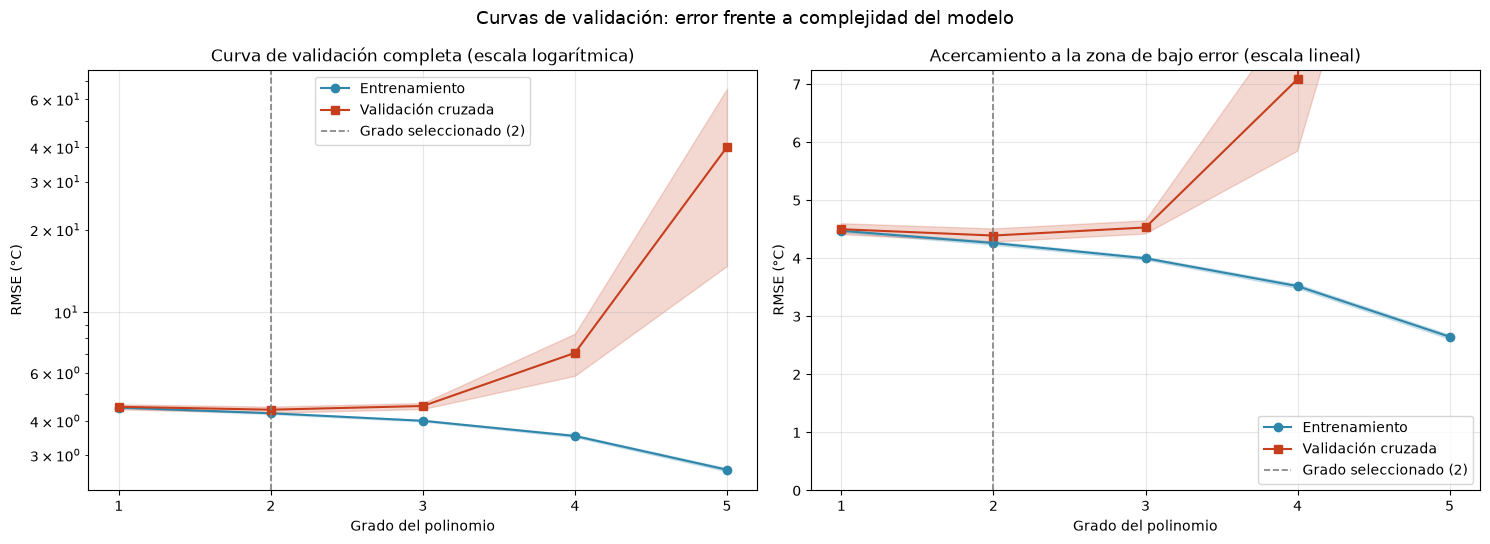

In [50]:
escalador_seleccionado = type(busqueda_polinomial.best_params_["escalado"]).__name__

curva = (
    resultados_polinomial[resultados_polinomial["escalado"] == escalador_seleccionado]
    .sort_values("poly__degree")
)

# La desviación del error de entrenamiento también se extrae de cv_results_
resultados_crudos = pd.DataFrame(busqueda_polinomial.cv_results_)
resultados_crudos["escalado"] = resultados_crudos["param_escalado"].apply(lambda e: type(e).__name__)
resultados_crudos = resultados_crudos[resultados_crudos["escalado"] == escalador_seleccionado]
resultados_crudos = resultados_crudos.sort_values("param_poly__degree")

grados = resultados_crudos["param_poly__degree"].astype(int).values
rmse_train = -resultados_crudos["mean_train_RMSE"].values
std_train = resultados_crudos["std_train_RMSE"].values
rmse_val = -resultados_crudos["mean_test_RMSE"].values
std_val = resultados_crudos["std_test_RMSE"].values

fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))

for eje, titulo, escala in [
    (ejes[0], "Curva de validación completa (escala logarítmica)", "log"),
    (ejes[1], "Acercamiento a la zona de bajo error (escala lineal)", "linear"),
]:
    eje.plot(grados, rmse_train, marker="o", color="#2E86AB", label="Entrenamiento")
    eje.fill_between(grados, rmse_train - std_train, rmse_train + std_train,
                     color="#2E86AB", alpha=0.20)
    eje.plot(grados, rmse_val, marker="s", color="#C73E1D", label="Validación cruzada")
    eje.fill_between(grados, rmse_val - std_val, rmse_val + std_val,
                     color="#C73E1D", alpha=0.20)
    eje.axvline(grado_optimo, color="gray", linestyle="--", linewidth=1.2,
                label=f"Grado seleccionado ({grado_optimo})")
    eje.set_yscale(escala)
    eje.set_xlabel("Grado del polinomio")
    eje.set_ylabel("RMSE (°C)")
    eje.set_title(titulo)
    eje.set_xticks(grados)
    eje.legend()
    eje.grid(alpha=0.3)

ejes[1].set_ylim(0, max(rmse_val[:3].max(), rmse_train.max()) * 1.6)

plt.suptitle("Curvas de validación: error frente a complejidad del modelo", fontsize=13)
plt.tight_layout()
plt.show()

In [51]:
# Lectura numérica de la curva: error, variabilidad y brecha por grado
curva_resumen = pd.DataFrame({
    "Grado": grados,
    "Columnas generadas": [comb(len(variables_reducidas) + int(g), int(g)) - 1 for g in grados],
    "RMSE_train": rmse_train,
    "RMSE_val": rmse_val,
    "Desv. estándar (val)": std_val,
    "Brecha val - train": rmse_val - rmse_train,
}).set_index("Grado")

curva_resumen.round(4)

,Columnas generadas,RMSE_train,RMSE_val,Desv. estándar (val),Brecha val - train
Grado,,,,,
1,8,4.4737,4.5011,0.0949,0.0274
2,44,4.2628,4.3921,0.1135,0.1292
3,164,4.0006,4.5310,0.1136,0.5305
4,494,3.5206,7.0864,1.2424,3.5658
5,1286,2.6486,40.1180,25.3859,37.4694


---

## Actividad 3. Modelos de regresión lineal regularizados (Ridge y Lasso)

En esta actividad cambiamos de estrategia para controlar la complejidad. En lugar de limitar el **número** de términos del modelo (como hicimos al elegir el grado), limitamos la **magnitud** de sus coeficientes añadiendo un término de penalización a la función de costo:

- **Ridge (L2):** minimiza $\sum(y_i - \hat{y}_i)^2 + \alpha \sum \beta_j^2$. Al penalizar el cuadrado de los coeficientes, los encoge todos hacia cero de forma suave, pero **ninguno llega exactamente a cero**. Es especialmente útil cuando hay variables correlacionadas entre sí (aquí, por ejemplo, `humedad_media`, `humedad_min` y `humedad_max`): en lugar de asignar un coeficiente enorme a una y otro enorme de signo contrario a la otra —lo que hace la regresión ordinaria y produce coeficientes inestables—, Ridge reparte el efecto entre ellas.
- **Lasso (L1):** minimiza $\sum(y_i - \hat{y}_i)^2 + \alpha \sum |\beta_j|$. El valor absoluto tiene una "esquina" en cero que hace que la solución óptima lleve coeficientes **exactamente a cero**. Esto convierte a Lasso en un método de **selección automática de características**.

En ambos casos, `alpha` controla la fuerza de la penalización: con `alpha → 0` el modelo tiende a la regresión ordinaria (mucha varianza) y con `alpha` muy grande todos los coeficientes se aproximan a cero y el modelo predice esencialmente la media (mucho sesgo). Encontrar el valor intermedio adecuado es un problema de búsqueda de hiperparámetros, exactamente como el grado del polinomio.

### Por qué el escalamiento es obligatorio aquí

En un modelo sin regularización, escalar es opcional (cambia los coeficientes pero no las predicciones). En Ridge y Lasso **no lo es**: la penalización se aplica por igual a todos los coeficientes, y el coeficiente de una variable depende de la escala en que esté medida. `presion_media` está en hectopascales (≈1.000) y `humedad_media` es una fracción entre 0 y 1; sin escalar, el coeficiente de la humedad tendría que ser mucho más grande para producir el mismo efecto y sería penalizado con mucha más fuerza. Escalar pone a todas las variables en igualdad de condiciones frente a la penalización.

### Configuración de la búsqueda

Usamos el **conjunto A (todas las variables)** porque el objetivo aquí es observar cómo la regularización actúa sobre un espacio amplio de predictores y, en el caso de Lasso, qué variables descarta. Las variables categóricas se codifican con `OneHotEncoder(handle_unknown="ignore")`, que crea una columna binaria por categoría y no falla si apareciera una categoría no vista en producción.

La malla de `alpha` se define en **escala logarítmica** (`np.logspace`) y no lineal, porque el efecto de la penalización es multiplicativo: la diferencia entre `alpha = 0.001` y `alpha = 0.01` es tan relevante como la que hay entre `alpha = 10` y `alpha = 100`. Una malla lineal desperdiciaría casi todos los puntos en la zona de penalización fuerte.

Se incluye además un **modelo sin regularización** con exactamente el mismo conjunto de variables y el mismo pipeline, para que la comparación de las tres alternativas sea limpia y atribuible únicamente al término de penalización.

In [52]:
def construir_preprocesador(escalador=None):
    '''ColumnTransformer: escala las numéricas y codifica las categóricas.'''
    return ColumnTransformer([
        ("num", escalador if escalador is not None else StandardScaler(), numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
    ])


# --- Modelo 1: regresión lineal SIN regularización (línea base) ---
pipeline_lineal = Pipeline([
    ("preprocesamiento", construir_preprocesador()),
    ("regresion", LinearRegression()),
])

# Aunque no tiene hiperparámetros de regularización, se pasa por GridSearchCV para
# (a) explorar también aquí la estrategia de escalamiento y (b) obtener las métricas
# de validación cruzada exactamente con el mismo procedimiento que los demás modelos.
malla_lineal = {"preprocesamiento__num": [StandardScaler(), MinMaxScaler()]}

busqueda_lineal = ejecutar_busqueda(
    pipeline_lineal, malla_lineal, X_train_completo, y_train,
    nombre="Lineal sin regularización (todas las variables)"
)

[Lineal sin regularización (todas las variables)]
  Combinaciones evaluadas: 2 (10 ajustes de modelo)
  Tiempo de búsqueda: 0.1 s
  Mejores hiperparámetros: {'preprocesamiento__num': StandardScaler()}
  RMSE en validación cruzada: 4.4065 °C


In [53]:
# --- Modelo 2: Ridge (penalización L2) ---
pipeline_ridge = Pipeline([
    ("preprocesamiento", construir_preprocesador()),
    ("regresion", Ridge(random_state=RANDOM_STATE)),
])

malla_ridge = {
    "preprocesamiento__num": [StandardScaler(), MinMaxScaler()],
    "regresion__alpha": np.logspace(-3, 3, 13),   # de 0.001 a 1000
}

busqueda_ridge = ejecutar_busqueda(
    pipeline_ridge, malla_ridge, X_train_completo, y_train,
    nombre="Ridge (L2)"
)

[Ridge (L2)]
  Combinaciones evaluadas: 26 (130 ajustes de modelo)
  Tiempo de búsqueda: 0.4 s
  Mejores hiperparámetros: {'preprocesamiento__num': MinMaxScaler(), 'regresion__alpha': np.float64(3.1622776601683795)}
  RMSE en validación cruzada: 4.3557 °C


In [54]:
# --- Modelo 3: Lasso (penalización L1) ---
# max_iter elevado porque el descenso por coordenadas de Lasso necesita más
# iteraciones cuando alpha es pequeño y hay variables correlacionadas.
pipeline_lasso = Pipeline([
    ("preprocesamiento", construir_preprocesador()),
    ("regresion", Lasso(max_iter=50_000, random_state=RANDOM_STATE)),
])

malla_lasso = {
    "preprocesamiento__num": [StandardScaler(), MinMaxScaler()],
    "regresion__alpha": np.logspace(-4, 1, 13),   # de 0.0001 a 10
}

busqueda_lasso = ejecutar_busqueda(
    pipeline_lasso, malla_lasso, X_train_completo, y_train,
    nombre="Lasso (L1)"
)

[Lasso (L1)]
  Combinaciones evaluadas: 26 (130 ajustes de modelo)
  Tiempo de búsqueda: 0.4 s
  Mejores hiperparámetros: {'preprocesamiento__num': MinMaxScaler(), 'regresion__alpha': np.float64(0.012115276586285889)}
  RMSE en validación cruzada: 4.3146 °C


### Efecto de `alpha` sobre el error de validación

La siguiente gráfica muestra la forma característica del compromiso sesgo-varianza en función de la penalización: a la izquierda (alpha pequeño) el modelo es prácticamente una regresión ordinaria; a la derecha (alpha grande) el modelo está tan penalizado que pierde capacidad de ajuste. El mínimo de cada curva marca el valor de `alpha` seleccionado.

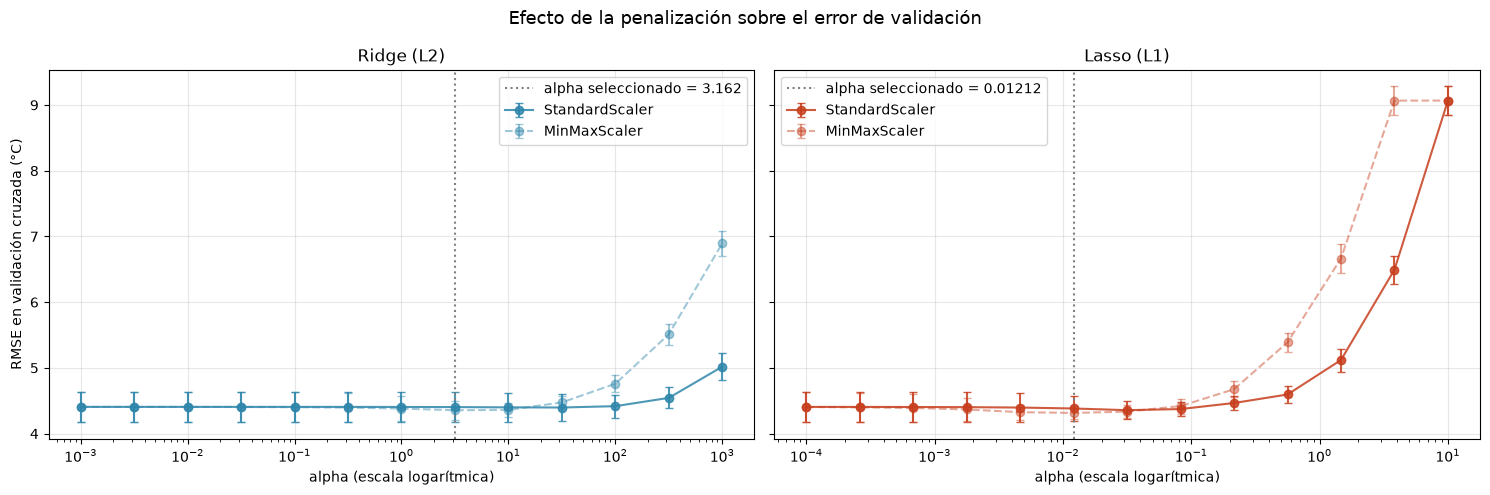

In [55]:
fig, ejes = plt.subplots(1, 2, figsize=(15, 5), sharey=True)

for eje, busqueda, titulo, color in [
    (ejes[0], busqueda_ridge, "Ridge (L2)", "#2E86AB"),
    (ejes[1], busqueda_lasso, "Lasso (L1)", "#C73E1D"),
]:
    tabla = tabla_resultados(busqueda)
    for escalador, estilo in [("StandardScaler", "-"), ("MinMaxScaler", "--")]:
        sub = tabla[tabla["preprocesamiento__num"] == escalador].sort_values("regresion__alpha")
        if sub.empty:
            continue
        eje.errorbar(
            sub["regresion__alpha"].astype(float), sub["RMSE_val"], yerr=sub["RMSE_val_std"],
            marker="o", linestyle=estilo, capsize=3, color=color, alpha=0.85 if estilo == "-" else 0.45,
            label=f"{escalador}",
        )
    mejor_alpha = busqueda.best_params_["regresion__alpha"]
    eje.axvline(mejor_alpha, color="gray", linestyle=":", linewidth=1.5,
                label=f"alpha seleccionado = {mejor_alpha:.4g}")
    eje.set_xscale("log")
    eje.set_xlabel("alpha (escala logarítmica)")
    eje.set_title(titulo)
    eje.grid(alpha=0.3)
    eje.legend()

ejes[0].set_ylabel("RMSE en validación cruzada (°C)")
plt.suptitle("Efecto de la penalización sobre el error de validación", fontsize=13)
plt.tight_layout()
plt.show()

In [56]:
# Registro de los tres modelos para la comparación final
for busqueda, nombre in [
    (busqueda_lineal, "Lineal sin regularización"),
    (busqueda_ridge, "Ridge (L2)"),
    (busqueda_lasso, "Lasso (L1)"),
]:
    resumenes_cv.append(resumen_validacion_cruzada(busqueda, nombre))
    resumenes_test.append(metricas_en_test(busqueda.best_estimator_, X_test_completo, y_test, nombre))

comparacion_regularizacion = (
    pd.DataFrame(resumenes_cv[-3:])
    .merge(pd.DataFrame(resumenes_test[-3:]), on="Modelo")
    .set_index("Modelo")
)
comparacion_regularizacion.round(4)

,RMSE_CV,RMSE_CV_std,MAE_CV,MAE_CV_std,R2_CV,R2_CV_std,RMSE_train_CV,RMSE_test,MAE_test,R2_test
Modelo,,,,,,,,,,
Lineal sin regularización,4.4065,0.2324,3.4648,0.1040,0.7631,0.0178,4.2488,4.3116,3.4563,0.7579
Ridge (L2),4.3557,0.1448,3.4549,0.0888,0.7685,0.0111,4.2585,4.3100,3.4466,0.7581
Lasso (L1),4.3146,0.0979,3.4388,0.0765,0.7728,0.0100,4.2631,4.3102,3.4489,0.7581


### Efecto de la regularización sobre los coeficientes

Comparamos ahora los coeficientes de los tres modelos. Como los tres usan exactamente las mismas variables y el mismo preprocesamiento, las diferencias son atribuibles únicamente al término de penalización. Nos interesan tres aspectos:

1. **Magnitud:** cuánto encoge cada método los coeficientes.
2. **Dispersión:** si hay coeficientes desproporcionadamente grandes (señal de colinealidad mal resuelta).
3. **Anulación:** cuántas variables lleva Lasso exactamente a cero, y cuáles.

*Nota de lectura:* los coeficientes están expresados sobre las variables ya escaladas, por lo que son comparables entre sí dentro de un mismo modelo. Si dos modelos seleccionaron estrategias de escalamiento distintas (`StandardScaler` frente a `MinMaxScaler`), la comparación de magnitudes **entre** modelos debe hacerse con cautela, porque el rango de las variables de entrada no es el mismo; por eso se imprime el escalador elegido por cada uno.

In [57]:
def extraer_coeficientes(modelo_ajustado, nombre):
    '''Devuelve los coeficientes con el nombre de la variable correspondiente.'''
    nombres = modelo_ajustado.named_steps["preprocesamiento"].get_feature_names_out()
    nombres = [n.replace("num__", "").replace("cat__", "") for n in nombres]
    return pd.Series(modelo_ajustado.named_steps["regresion"].coef_, index=nombres, name=nombre)


for nombre, busqueda in [("Sin regularización", busqueda_lineal),
                         ("Ridge", busqueda_ridge),
                         ("Lasso", busqueda_lasso)]:
    escalador = busqueda.best_estimator_.named_steps["preprocesamiento"].named_transformers_["num"]
    print(f"{nombre:<20} escalador seleccionado: {type(escalador).__name__}")
print()

coeficientes = pd.concat([
    extraer_coeficientes(busqueda_lineal.best_estimator_, "Sin regularización"),
    extraer_coeficientes(busqueda_ridge.best_estimator_, "Ridge"),
    extraer_coeficientes(busqueda_lasso.best_estimator_, "Lasso"),
], axis=1)

resumen_coeficientes = pd.DataFrame({
    "Suma de |coeficientes|": coeficientes.abs().sum(),
    "Coeficiente máximo |.|": coeficientes.abs().max(),
    "Coeficiente promedio |.|": coeficientes.abs().mean(),
    "Coeficientes exactamente en cero": (coeficientes == 0).sum(),
    "Total de coeficientes": len(coeficientes),
})
resumen_coeficientes.round(4)

Sin regularización   escalador seleccionado: StandardScaler
Ridge                escalador seleccionado: MinMaxScaler
Lasso                escalador seleccionado: MinMaxScaler



,Suma de |coeficientes|,Coeficiente máximo |.|,Coeficiente promedio |.|,Coeficientes exactamente en cero,Total de coeficientes
Sin regularización,27.2909,5.9521,0.8804,0,31
Ridge,56.6722,15.7465,1.8281,0,31
Lasso,49.0634,16.9359,1.5827,13,31


In [58]:
# Variables anuladas y conservadas por Lasso
anuladas = coeficientes.index[coeficientes["Lasso"] == 0].tolist()
conservadas = (
    coeficientes.loc[coeficientes["Lasso"] != 0, "Lasso"]
    .sort_values(key=np.abs, ascending=False)
)

print(f"Variables llevadas a CERO por Lasso ({len(anuladas)} de {len(coeficientes)}):")
for variable in anuladas:
    print(f"  - {variable}")

print()
print(f"Variables CONSERVADAS por Lasso ({len(conservadas)}), ordenadas por importancia:")
print(conservadas.round(4).to_string())

Variables llevadas a CERO por Lasso (13 de 31):
  - presion_min
  - presion_max
  - presion_desv
  - humedad_min
  - viento_media
  - viento_min
  - viento_desv
  - rafaga_min
  - rafaga_max
  - rafaga_desv
  - direccion_viento
  - estacion_anio_primavera
  - sector_viento_SE

Variables CONSERVADAS por Lasso (18), ordenadas por importancia:
dia_cos                  -16.9359
humedad_media             -6.1290
dia_sin                   -5.0377
humedad_desv               4.0773
presion_media              2.9719
sector_viento_N           -2.1467
sector_viento_NO          -1.9856
sector_viento_O           -1.9394
sector_viento_S            1.5193
estacion_anio_invierno    -1.4960
sector_viento_E            1.4093
sector_viento_NE          -1.2056
rafaga_media              -0.8210
viento_max                 0.4649
estacion_anio_otoño       -0.3251
sector_viento_SO           0.2444
estacion_anio_verano       0.1850
humedad_max                0.1694


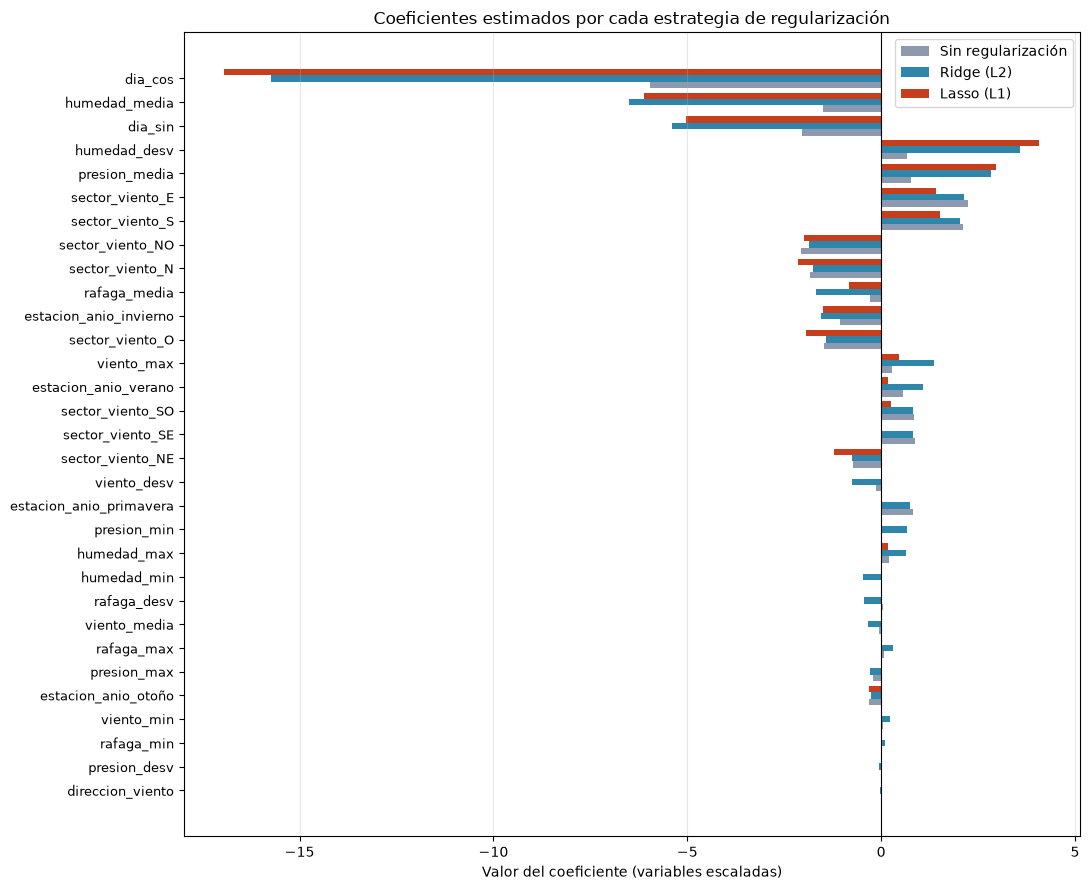

In [59]:
# Comparación visual de los coeficientes de los tres modelos
orden = coeficientes["Ridge"].abs().sort_values(ascending=True).index
coeficientes_ordenados = coeficientes.loc[orden]

fig, eje = plt.subplots(figsize=(11, 9))
posiciones = np.arange(len(coeficientes_ordenados))
ancho = 0.27

eje.barh(posiciones - ancho, coeficientes_ordenados["Sin regularización"], ancho,
         label="Sin regularización", color="#8D99AE")
eje.barh(posiciones, coeficientes_ordenados["Ridge"], ancho, label="Ridge (L2)", color="#2E86AB")
eje.barh(posiciones + ancho, coeficientes_ordenados["Lasso"], ancho, label="Lasso (L1)", color="#C73E1D")

eje.set_yticks(posiciones)
eje.set_yticklabels(coeficientes_ordenados.index, fontsize=9)
eje.axvline(0, color="black", linewidth=0.8)
eje.set_xlabel("Valor del coeficiente (variables escaladas)")
eje.set_title("Coeficientes estimados por cada estrategia de regularización")
eje.legend()
eje.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

### Comparación controlada: los tres modelos bajo un escalador común

La tabla anterior tiene un problema de interpretación que conviene resolver antes de sacar conclusiones: **los tres modelos no eligieron el mismo escalador**. `MinMaxScaler` deja las variables en el rango [0, 1] (desviación típica ≈ 0,2) mientras que `StandardScaler` las deja con desviación 1. Como el coeficiente compensa la escala de su variable, un modelo con `MinMaxScaler` produce coeficientes mecánicamente unas cinco veces más grandes, **sin que eso signifique que esté menos regularizado**. Comparar magnitudes entre modelos con escaladores distintos llevaría a la conclusión errónea de que la regularización *aumentó* los coeficientes.

Para aislar el efecto real de la penalización repetimos la comparación **fijando `StandardScaler` en los tres modelos** y conservando los valores de `alpha` seleccionados por la búsqueda. Así, la única diferencia entre los tres ajustes es el término de penalización, que es exactamente lo que queremos medir.

In [60]:
def construir_modelo_escalado_fijo(regresor):
    '''Pipeline con StandardScaler fijo, para comparar los tres modelos en igualdad de condiciones.'''
    return Pipeline([
        ("preprocesamiento", ColumnTransformer([
            ("num", StandardScaler(), numericas),
            ("cat", OneHotEncoder(handle_unknown="ignore"), categoricas),
        ])),
        ("regresion", regresor),
    ])


alpha_ridge = busqueda_ridge.best_params_["regresion__alpha"]
alpha_lasso = busqueda_lasso.best_params_["regresion__alpha"]

modelos_comparables = {
    "Sin regularización": construir_modelo_escalado_fijo(LinearRegression()),
    "Ridge": construir_modelo_escalado_fijo(Ridge(alpha=alpha_ridge, random_state=RANDOM_STATE)),
    "Lasso": construir_modelo_escalado_fijo(
        Lasso(alpha=alpha_lasso, max_iter=50_000, random_state=RANDOM_STATE)
    ),
}

coeficientes_comparables = {}
for nombre, modelo in modelos_comparables.items():
    modelo.fit(X_train_completo, y_train)
    coeficientes_comparables[nombre] = extraer_coeficientes(modelo, nombre)

coeficientes_comparables = pd.DataFrame(coeficientes_comparables)

print(f"alpha de Ridge: {alpha_ridge:.4f}   |   alpha de Lasso: {alpha_lasso:.4f}")
print()
pd.DataFrame({
    "Suma de |coeficientes|": coeficientes_comparables.abs().sum(),
    "Coeficiente máximo |.|": coeficientes_comparables.abs().max(),
    "Coeficiente promedio |.|": coeficientes_comparables.abs().mean(),
    "Coeficientes en cero": (coeficientes_comparables == 0).sum(),
}).round(4)

alpha de Ridge: 3.1623   |   alpha de Lasso: 0.0121



,Suma de |coeficientes|,Coeficiente máximo |.|,Coeficiente promedio |.|,Coeficientes en cero
Sin regularización,27.2909,5.9521,0.8804,0
Ridge,26.7307,5.9022,0.8623,0
Lasso,23.6176,6.0461,0.7619,7


In [61]:
# Variables anuladas por Lasso bajo el escalador común
anuladas_comparables = coeficientes_comparables.index[coeficientes_comparables["Lasso"] == 0].tolist()

print(f"Con StandardScaler, Lasso anula {len(anuladas_comparables)} de {len(coeficientes_comparables)} coeficientes:")
for variable in anuladas_comparables:
    print(f"  - {variable}")
print()
print(f"Con el escalador que eligió la búsqueda (MinMaxScaler), Lasso anulaba {len(anuladas)}.")
print("La cantidad de variables descartadas depende de la escala de entrada: es una decisión")
print("del preprocesamiento tanto como del método de regularización.")

Con StandardScaler, Lasso anula 7 de 31 coeficientes:
  - presion_desv
  - humedad_min
  - viento_media
  - rafaga_min
  - rafaga_desv
  - direccion_viento
  - sector_viento_SE

Con el escalador que eligió la búsqueda (MinMaxScaler), Lasso anulaba 13.
La cantidad de variables descartadas depende de la escala de entrada: es una decisión
del preprocesamiento tanto como del método de regularización.


### Estabilidad de los coeficientes

El enunciado pregunta explícitamente por el efecto de la regularización sobre la **estabilidad** de los coeficientes, no solo sobre su magnitud. Para responderlo con evidencia y no con teoría, hacemos un experimento: reentrenamos los tres modelos comparables sobre 40 remuestreos *bootstrap* del conjunto de entrenamiento y medimos **cuánto varía cada coeficiente entre remuestreos**. Un coeficiente estable es aquel cuyo valor cambia poco cuando cambian ligeramente los datos; un coeficiente inestable es el síntoma clásico de colinealidad y de un modelo con alta varianza.

Se usan los modelos con escalador común y los `alpha` ya seleccionados, porque lo que queremos aislar es la variabilidad del ajuste frente a los datos, no la de la búsqueda ni la del preprocesamiento.

In [62]:
generador = np.random.default_rng(RANDOM_STATE)
n_remuestreos = 40

variabilidad = {}
for nombre, modelo in modelos_comparables.items():
    coeficientes_remuestreo = []
    for _ in range(n_remuestreos):
        indices = generador.choice(len(X_train_completo), size=len(X_train_completo), replace=True)
        modelo_remuestreo = clone(modelo)
        modelo_remuestreo.fit(X_train_completo.iloc[indices], y_train.iloc[indices])
        coeficientes_remuestreo.append(modelo_remuestreo.named_steps["regresion"].coef_)
    variabilidad[nombre] = np.std(np.vstack(coeficientes_remuestreo), axis=0)

variabilidad = pd.DataFrame(variabilidad, index=coeficientes_comparables.index)

print(f"Desviación estándar de cada coeficiente a lo largo de {n_remuestreos} remuestreos bootstrap")
print("(todos los modelos con StandardScaler, por lo que las cifras son comparables entre sí)")
print()
print("Resumen por modelo:")
print(pd.DataFrame({
    "Desviación promedio": variabilidad.mean(),
    "Desviación máxima": variabilidad.max(),
    "Variable más inestable": variabilidad.idxmax(),
}).round(4).to_string())
print()
print("Detalle por variable (las 10 más inestables sin regularización):")
print(variabilidad.sort_values("Sin regularización", ascending=False).head(10).round(4).to_string())

Desviación estándar de cada coeficiente a lo largo de 40 remuestreos bootstrap
(todos los modelos con StandardScaler, por lo que las cifras son comparables entre sí)

Resumen por modelo:
                    Desviación promedio  Desviación máxima Variable más inestable
Sin regularización               0.2968             0.7804       sector_viento_NO
Ridge                            0.3034             0.7493       sector_viento_NO
Lasso                            0.2937             0.8633       sector_viento_NO

Detalle por variable (las 10 más inestables sin regularización):
                         Sin regularización  Ridge  Lasso
sector_viento_NO                     0.7804 0.7493 0.8633
sector_viento_SE                     0.7730 0.5459 0.3305
sector_viento_E                      0.5980 0.5946 0.8053
sector_viento_N                      0.4578 0.4014 0.5685
sector_viento_NE                     0.4531 0.5191 0.4935
sector_viento_O                      0.3434 0.3420 0.5043
estacion_anio

## Actividad 4. Modelo de regresión polinomial regularizado

Las dos actividades anteriores atacaron el problema de la complejidad por caminos distintos: la Actividad 1 la controló **limitando el grado** y la Actividad 3 **penalizando la magnitud de los coeficientes**. Aquí combinamos ambos mecanismos para responder la pregunta que plantea el enunciado: **¿permite la regularización aumentar la complejidad del modelo sin caer en sobreajuste?**

La hipótesis es que sí. En la Actividad 2 vimos que a partir de cierto grado el modelo sin regularización se dispara porque, al haber casi tantas columnas como filas, puede ajustar el ruido de los datos de entrenamiento asignando coeficientes enormes. La penalización impide justamente eso: aunque las columnas de grado alto estén disponibles, el modelo solo las usará si su aporte compensa el costo de tener un coeficiente grande. Si la hipótesis es correcta, deberíamos observar que **la curva de error de los modelos regularizados no se dispara** en los grados altos, sino que se aplana.

El pipeline es el mismo de la Actividad 1 con el regresor sustituido, y la búsqueda explora ahora **tres hiperparámetros simultáneamente**: grado, escalador y alpha. El espacio de búsqueda es el producto cartesiano de las tres dimensiones, de modo que el costo crece multiplicativamente; por eso la malla de `alpha` es más corta aquí que en la Actividad 3: 6 valores logarítmicamente espaciados para Ridge y 4 para Lasso. La malla de Lasso se acorta aún más porque su algoritmo (descenso por coordenadas) es iterativo y su costo se dispara cuando `alpha` es pequeño y hay más de mil columnas polinomiales — precisamente las combinaciones que, por construcción, iban a quedar descartadas por sobreajuste. Esta es la advertencia que hace el propio enunciado sobre el tiempo que puede tomar la búsqueda: la malla se diseña para cubrir el rango relevante, no para ser exhaustiva.

In [63]:
# --- Polinomial + Ridge ---
pipeline_poly_ridge = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("escalado", StandardScaler()),
    ("regresion", Ridge(random_state=RANDOM_STATE)),
])

malla_poly_ridge = {
    "poly__degree": [1, 2, 3, 4, 5],
    "escalado": [StandardScaler(), MinMaxScaler()],
    "regresion__alpha": np.logspace(-2, 3, 6),
}

busqueda_poly_ridge = ejecutar_busqueda(
    pipeline_poly_ridge, malla_poly_ridge, X_train_reducido, y_train,
    nombre="Polinomial + Ridge"
)

[Polinomial + Ridge]
  Combinaciones evaluadas: 60 (300 ajustes de modelo)
  Tiempo de búsqueda: 7.8 s
  Mejores hiperparámetros: {'escalado': MinMaxScaler(), 'poly__degree': 4, 'regresion__alpha': np.float64(1.0)}
  RMSE en validación cruzada: 4.3512 °C


In [64]:
# --- Polinomial + Lasso ---
pipeline_poly_lasso = Pipeline([
    ("poly", PolynomialFeatures(include_bias=False)),
    ("escalado", StandardScaler()),
    ("regresion", Lasso(max_iter=5_000, tol=1e-3, random_state=RANDOM_STATE)),
])

malla_poly_lasso = {
    "poly__degree": [1, 2, 3, 4, 5],
    "escalado": [StandardScaler(), MinMaxScaler()],
    "regresion__alpha": [0.01, 0.05, 0.2, 1.0],
}

busqueda_poly_lasso = ejecutar_busqueda(
    pipeline_poly_lasso, malla_poly_lasso, X_train_reducido, y_train,
    nombre="Polinomial + Lasso"
)

[Polinomial + Lasso]
  Combinaciones evaluadas: 40 (200 ajustes de modelo)
  Tiempo de búsqueda: 21.6 s
  Mejores hiperparámetros: {'escalado': StandardScaler(), 'poly__degree': 4, 'regresion__alpha': 0.01}
  RMSE en validación cruzada: 4.3628 °C


In [65]:
resultados_poly_ridge = tabla_resultados(busqueda_poly_ridge)
resultados_poly_lasso = tabla_resultados(busqueda_poly_lasso)

print("Mejores 8 combinaciones — Polinomial + Ridge")
print(resultados_poly_ridge.head(8).round(4).to_string(index=False))
print()
print("Mejores 8 combinaciones — Polinomial + Lasso")
print(resultados_poly_lasso.head(8).round(4).to_string(index=False))

Mejores 8 combinaciones — Polinomial + Ridge
      escalado  poly__degree  regresion__alpha  RMSE_train  RMSE_val  RMSE_val_std  MAE_val  R2_val  Brecha (val - train)
  MinMaxScaler             4            1.0000      4.1409    4.3512        0.0896   3.4705  0.7689                0.2103
  MinMaxScaler             5            1.0000      4.0409    4.3612        0.0744   3.4888  0.7679                0.3204
  MinMaxScaler             3            0.1000      4.1511    4.3644        0.0886   3.4842  0.7675                0.2134
  MinMaxScaler             3            1.0000      4.2409    4.3680        0.0943   3.4804  0.7671                0.1271
StandardScaler             3           10.0000      4.1920    4.3712        0.0897   3.4852  0.7668                0.1792
StandardScaler             4           10.0000      4.0596    4.3712        0.0773   3.4885  0.7668                0.3117
  MinMaxScaler             5           10.0000      4.2056    4.3719        0.0824   3.4782  0.7668  

### ¿Controla la regularización el sobreajuste al aumentar el grado?

Para responder esta pregunta graficamos, para cada grado, el **mejor RMSE de validación alcanzable** por cada una de las tres estrategias (sin regularización, con Ridge y con Lasso). Es decir, para cada grado se toma la mejor combinación de los demás hiperparámetros. Si la regularización cumple su función, las curvas de Ridge y Lasso deberían mantenerse planas justamente donde la del modelo sin regularización se dispara.

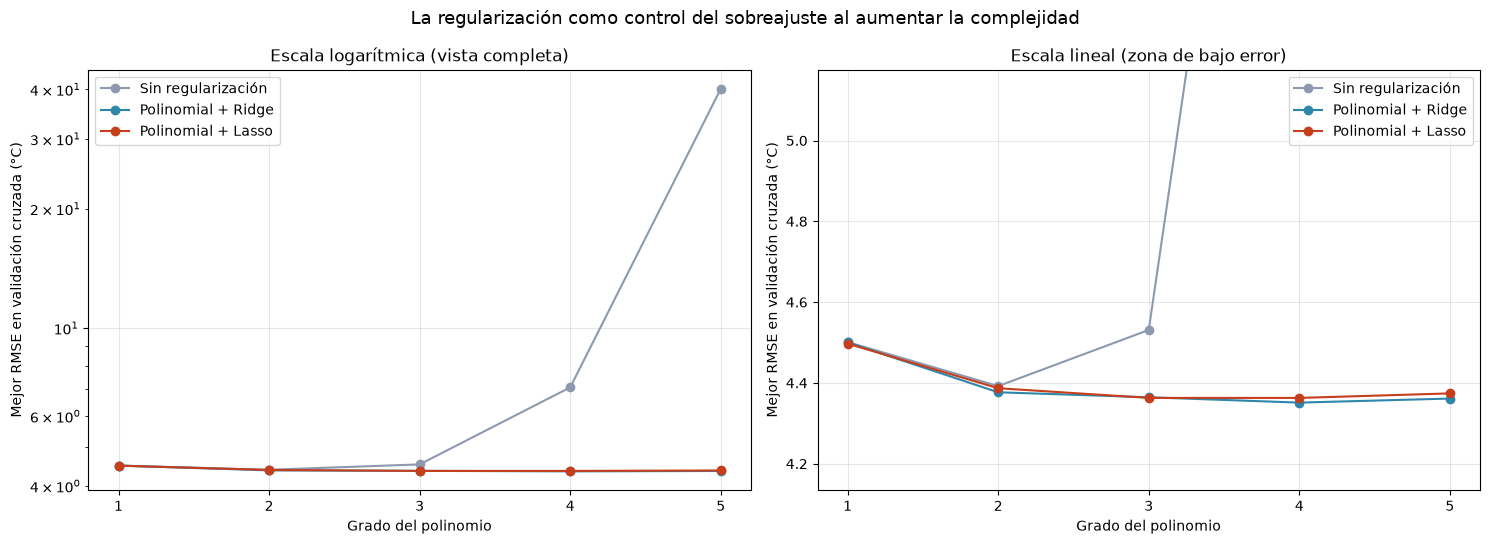

,Sin regularización,Polinomial + Ridge,Polinomial + Lasso
poly__degree,,,
1,4.5011,4.5003,4.4972
2,4.3921,4.3768,4.3869
3,4.5310,4.3644,4.3629
4,7.0864,4.3512,4.3628
5,40.1180,4.3612,4.3740


In [66]:
def mejor_por_grado(tabla):
    return tabla.groupby("poly__degree")["RMSE_val"].min().sort_index()

mejores_por_grado = pd.DataFrame({
    "Sin regularización": mejor_por_grado(resultados_polinomial),
    "Polinomial + Ridge": mejor_por_grado(resultados_poly_ridge),
    "Polinomial + Lasso": mejor_por_grado(resultados_poly_lasso),
})

fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))

colores = {"Sin regularización": "#8D99AE", "Polinomial + Ridge": "#2E86AB", "Polinomial + Lasso": "#C73E1D"}
for eje, escala, titulo in [
    (ejes[0], "log", "Escala logarítmica (vista completa)"),
    (ejes[1], "linear", "Escala lineal (zona de bajo error)"),
]:
    for columna in mejores_por_grado.columns:
        eje.plot(mejores_por_grado.index, mejores_por_grado[columna],
                 marker="o", label=columna, color=colores[columna])
    eje.set_yscale(escala)
    eje.set_xlabel("Grado del polinomio")
    eje.set_ylabel("Mejor RMSE en validación cruzada (°C)")
    eje.set_title(titulo)
    eje.set_xticks(mejores_por_grado.index)
    eje.grid(alpha=0.3)
    eje.legend()

ejes[1].set_ylim(
    mejores_por_grado.min().min() * 0.95,
    mejores_por_grado[["Polinomial + Ridge", "Polinomial + Lasso"]].max().max() * 1.15,
)

plt.suptitle("La regularización como control del sobreajuste al aumentar la complejidad", fontsize=13)
plt.tight_layout()
plt.show()

mejores_por_grado.round(4)

In [67]:
for busqueda, nombre in [
    (busqueda_poly_ridge, "Polinomial + Ridge"),
    (busqueda_poly_lasso, "Polinomial + Lasso"),
]:
    resumenes_cv.append(resumen_validacion_cruzada(busqueda, nombre))
    resumenes_test.append(metricas_en_test(busqueda.best_estimator_, X_test_reducido, y_test, nombre))

pd.DataFrame(resumenes_cv[-2:]).merge(pd.DataFrame(resumenes_test[-2:]), on="Modelo").set_index("Modelo").round(4)

,RMSE_CV,RMSE_CV_std,MAE_CV,MAE_CV_std,R2_CV,R2_CV_std,RMSE_train_CV,RMSE_test,MAE_test,R2_test
Modelo,,,,,,,,,,
Polinomial + Ridge,4.3512,0.0896,3.4705,0.0861,0.7689,0.0091,4.1409,4.2869,3.3522,0.7607
Polinomial + Lasso,4.3628,0.0904,3.4811,0.0904,0.7677,0.0089,4.1408,4.2835,3.3484,0.7611


## Actividad 5. Comparación y selección del mejor modelo

Reunimos los cinco modelos construidos en una única tabla. El criterio de selección **no es únicamente el RMSE promedio**, tal como advierte el enunciado. Consideramos tres dimensiones:

1. **Desempeño:** RMSE promedio en validación cruzada (métrica principal), acompañado de MAE y R².
2. **Estabilidad:** desviación estándar del RMSE entre los 5 *folds*. Un modelo con RMSE promedio ligeramente mejor pero con el doble de desviación estándar es un modelo cuyo desempeño real es mucho menos predecible; en producción, eso significa que habrá periodos con errores considerablemente mayores que el promedio anunciado.
3. **Complejidad:** número de columnas que el modelo necesita y facilidad de interpretación y mantenimiento. A igualdad de desempeño, siempre se prefiere el modelo más simple (principio de parsimonia): es más barato de mantener, más fácil de explicar al negocio y menos frágil ante cambios en los datos.

Se añade también la columna **`Diferencia CV vs test`**: si el desempeño en test fuera mucho peor que el estimado por validación cruzada, sería una señal de que el proceso de selección de hiperparámetros se sobreajustó a los *folds*.

In [68]:
tabla_comparativa = (
    pd.DataFrame(resumenes_cv)
    .merge(pd.DataFrame(resumenes_test), on="Modelo")
    .set_index("Modelo")
)

tabla_comparativa["Diferencia CV vs test"] = (
    tabla_comparativa["RMSE_test"] - tabla_comparativa["RMSE_CV"]
)
tabla_comparativa["Brecha train-val (CV)"] = (
    tabla_comparativa["RMSE_CV"] - tabla_comparativa["RMSE_train_CV"]
)

columnas_presentacion = [
    "RMSE_CV", "RMSE_CV_std", "MAE_CV", "R2_CV",
    "RMSE_test", "MAE_test", "R2_test",
    "Diferencia CV vs test", "Brecha train-val (CV)",
]

tabla_comparativa[columnas_presentacion].sort_values("RMSE_CV").round(4)

,RMSE_CV,RMSE_CV_std,MAE_CV,R2_CV,RMSE_test,MAE_test,R2_test,Diferencia CV vs test,Brecha train-val (CV)
Modelo,,,,,,,,,
Lasso (L1),4.3146,0.0979,3.4388,0.7728,4.3102,3.4489,0.7581,-0.0044,0.0515
Polinomial + Ridge,4.3512,0.0896,3.4705,0.7689,4.2869,3.3522,0.7607,-0.0644,0.2103
Ridge (L2),4.3557,0.1448,3.4549,0.7685,4.3100,3.4466,0.7581,-0.0457,0.0972
Polinomial + Lasso,4.3628,0.0904,3.4811,0.7677,4.2835,3.3484,0.7611,-0.0794,0.2220
Polinomial (sin regularización),4.3921,0.1135,3.5024,0.7645,4.3498,3.4101,0.7536,-0.0423,0.1292
Lineal sin regularización,4.4065,0.2324,3.4648,0.7631,4.3116,3.4563,0.7579,-0.0950,0.1577


In [69]:
# Hiperparámetros seleccionados por cada búsqueda
busquedas = {
    "Polinomial (sin regularización)": busqueda_polinomial,
    "Lineal sin regularización": busqueda_lineal,
    "Ridge (L2)": busqueda_ridge,
    "Lasso (L1)": busqueda_lasso,
    "Polinomial + Ridge": busqueda_poly_ridge,
    "Polinomial + Lasso": busqueda_poly_lasso,
}

for nombre, busqueda in busquedas.items():
    parametros = {
        clave: (type(valor).__name__ if hasattr(valor, "fit") else valor)
        for clave, valor in busqueda.best_params_.items()
    }
    print(f"{nombre}")
    print(f"   Hiperparámetros: {parametros}")
    print(f"   RMSE (CV) = {-busqueda.best_score_:.4f} °C")
    print()

Polinomial (sin regularización)
   Hiperparámetros: {'escalado': 'MinMaxScaler', 'poly__degree': 2}
   RMSE (CV) = 4.3921 °C

Lineal sin regularización
   Hiperparámetros: {'preprocesamiento__num': 'StandardScaler'}
   RMSE (CV) = 4.4065 °C

Ridge (L2)
   Hiperparámetros: {'preprocesamiento__num': 'MinMaxScaler', 'regresion__alpha': np.float64(3.1622776601683795)}
   RMSE (CV) = 4.3557 °C

Lasso (L1)
   Hiperparámetros: {'preprocesamiento__num': 'MinMaxScaler', 'regresion__alpha': np.float64(0.012115276586285889)}
   RMSE (CV) = 4.3146 °C

Polinomial + Ridge
   Hiperparámetros: {'escalado': 'MinMaxScaler', 'poly__degree': 4, 'regresion__alpha': np.float64(1.0)}
   RMSE (CV) = 4.3512 °C

Polinomial + Lasso
   Hiperparámetros: {'escalado': 'StandardScaler', 'poly__degree': 4, 'regresion__alpha': 0.01}
   RMSE (CV) = 4.3628 °C



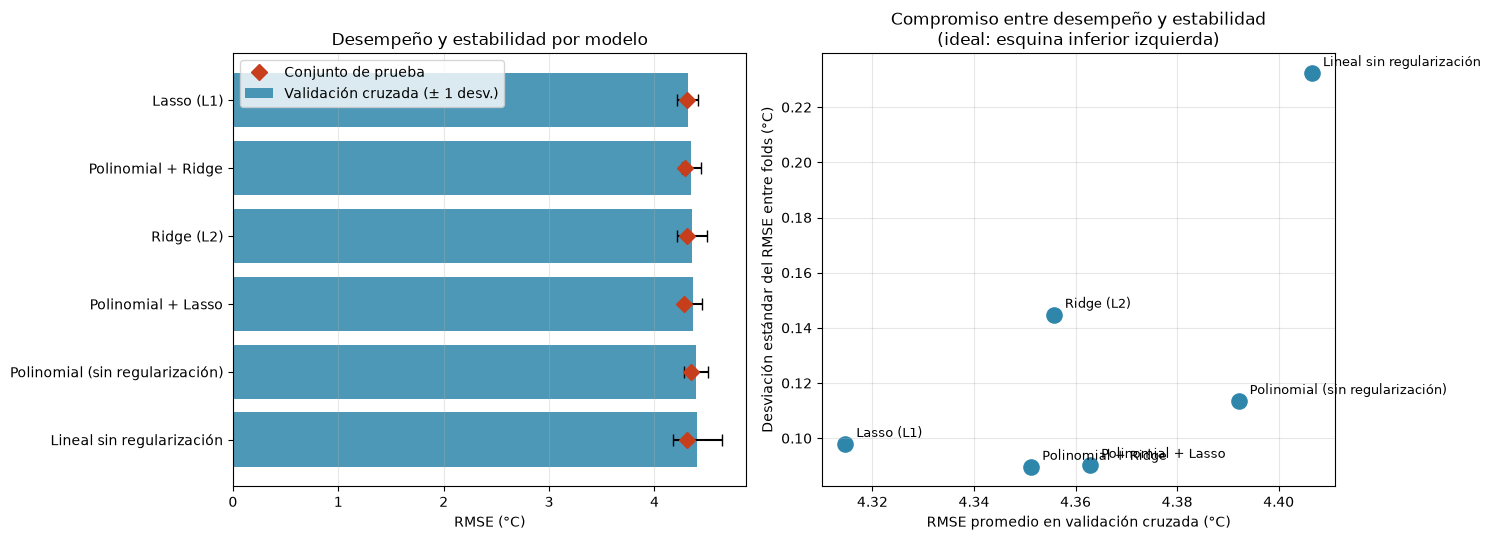

In [70]:
# Visualización de la comparación: desempeño y estabilidad en una sola lectura
orden_modelos = tabla_comparativa.sort_values("RMSE_CV").index

fig, ejes = plt.subplots(1, 2, figsize=(15, 5.5))

posiciones = np.arange(len(orden_modelos))
ejes[0].barh(posiciones, tabla_comparativa.loc[orden_modelos, "RMSE_CV"],
             xerr=tabla_comparativa.loc[orden_modelos, "RMSE_CV_std"],
             color="#2E86AB", alpha=0.85, capsize=4, label="Validación cruzada (± 1 desv.)")
ejes[0].plot(tabla_comparativa.loc[orden_modelos, "RMSE_test"], posiciones,
             "D", color="#C73E1D", markersize=8, label="Conjunto de prueba")
ejes[0].set_yticks(posiciones)
ejes[0].set_yticklabels(orden_modelos)
ejes[0].invert_yaxis()
ejes[0].set_xlabel("RMSE (°C)")
ejes[0].set_title("Desempeño y estabilidad por modelo")
ejes[0].legend()
ejes[0].grid(axis="x", alpha=0.3)

ejes[1].scatter(tabla_comparativa["RMSE_CV"], tabla_comparativa["RMSE_CV_std"],
                s=120, color="#2E86AB")
for nombre in tabla_comparativa.index:
    ejes[1].annotate(nombre,
                     (tabla_comparativa.loc[nombre, "RMSE_CV"], tabla_comparativa.loc[nombre, "RMSE_CV_std"]),
                     textcoords="offset points", xytext=(8, 5), fontsize=9)
ejes[1].set_xlabel("RMSE promedio en validación cruzada (°C)")
ejes[1].set_ylabel("Desviación estándar del RMSE entre folds (°C)")
ejes[1].set_title("Compromiso entre desempeño y estabilidad\n(ideal: esquina inferior izquierda)")
ejes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [71]:
# Selección automática del mejor modelo según el RMSE promedio en validación cruzada
nombre_mejor = tabla_comparativa["RMSE_CV"].idxmin()
busqueda_final = busquedas[nombre_mejor]
modelo_final = busqueda_final.best_estimator_

# Cada modelo se entrenó sobre uno de los dos espacios de variables
usa_conjunto_reducido = "Polinomial" in nombre_mejor and "Lineal" not in nombre_mejor
X_test_final = X_test_reducido if usa_conjunto_reducido else X_test_completo
X_train_final = X_train_reducido if usa_conjunto_reducido else X_train_completo

print(f"Modelo con menor RMSE promedio en validación cruzada: {nombre_mejor}")
print(f"Conjunto de variables: {'B (reducido, 8 variables)' if usa_conjunto_reducido else 'A (completo, 21 variables)'}")
print(f"Hiperparámetros: {busqueda_final.best_params_}")
print()
print(tabla_comparativa.loc[[nombre_mejor], columnas_presentacion].round(4).T)

Modelo con menor RMSE promedio en validación cruzada: Lasso (L1)
Conjunto de variables: A (completo, 21 variables)
Hiperparámetros: {'preprocesamiento__num': MinMaxScaler(), 'regresion__alpha': np.float64(0.012115276586285889)}

Modelo                 Lasso (L1)
RMSE_CV                    4.3146
RMSE_CV_std                0.0979
MAE_CV                     3.4388
R2_CV                      0.7728
RMSE_test                  4.3102
MAE_test                   3.4489
R2_test                    0.7581
Diferencia CV vs test     -0.0044
Brecha train-val (CV)      0.0515


## Actividad 6. Construcción de intervalos de confianza mediante *bootstrapping*

Las métricas reportadas hasta ahora sobre el conjunto de prueba son **una sola estimación puntual** calculada sobre una única muestra de ~597 días. Si AlpesPlanck hubiera recogido otros 597 días distintos, el RMSE habría dado un valor algo diferente. La pregunta que responde esta actividad es: **¿qué tan diferente?**

El *bootstrapping* responde justamente eso sin necesidad de recolectar datos nuevos. El procedimiento es:

1. Se toma el conjunto de prueba y se generan **1.000 remuestreos con reemplazo** del mismo tamaño (el enunciado pide al menos 500; usamos el doble porque el costo es despreciable —solo se recalculan métricas sobre predicciones ya hechas— y con más remuestreos los percentiles del intervalo son más precisos).
2. En cada remuestreo se recalculan RMSE, MAE y R².
3. Los percentiles 2,5 y 97,5 de las 1.000 métricas obtenidas conforman el **intervalo de confianza al 95 %** (método de percentiles).

**Detalle metodológico importante:** el modelo **no se reentrena** en cada remuestreo. Se remuestrea el conjunto de evaluación, no el de entrenamiento, porque lo que queremos cuantificar es la incertidumbre asociada a *sobre qué días estamos midiendo* el desempeño de un modelo ya fijo — que es la pregunta relevante para decidir si se puede confiar en el número que se le reporta al negocio. Reentrenar en cada remuestreo respondería una pregunta distinta (la variabilidad del procedimiento de entrenamiento) y costaría mil veces más.

In [72]:
predicciones_test = modelo_final.predict(X_test_final)
residuales = y_test.values - predicciones_test

n_remuestreos_bootstrap = 1_000
generador_bootstrap = np.random.default_rng(RANDOM_STATE)
indices_test = np.arange(len(y_test))

metricas_bootstrap = []
for _ in range(n_remuestreos_bootstrap):
    muestra = generador_bootstrap.choice(indices_test, size=len(indices_test), replace=True)
    y_muestra = y_test.values[muestra]
    prediccion_muestra = predicciones_test[muestra]
    metricas_bootstrap.append({
        "RMSE": root_mean_squared_error(y_muestra, prediccion_muestra),
        "MAE": mean_absolute_error(y_muestra, prediccion_muestra),
        "R2": r2_score(y_muestra, prediccion_muestra),
    })

metricas_bootstrap = pd.DataFrame(metricas_bootstrap)

intervalos = pd.DataFrame({
    "Estimación puntual (test)": {
        "RMSE": root_mean_squared_error(y_test, predicciones_test),
        "MAE": mean_absolute_error(y_test, predicciones_test),
        "R2": r2_score(y_test, predicciones_test),
    },
    "Media bootstrap": metricas_bootstrap.mean(),
    "Desviación estándar": metricas_bootstrap.std(),
    "Límite inferior (2.5%)": metricas_bootstrap.quantile(0.025),
    "Límite superior (97.5%)": metricas_bootstrap.quantile(0.975),
})
intervalos["Amplitud del IC"] = intervalos["Límite superior (97.5%)"] - intervalos["Límite inferior (2.5%)"]
intervalos["Amplitud relativa (%)"] = 100 * intervalos["Amplitud del IC"] / intervalos["Media bootstrap"].abs()

print(f"Modelo evaluado: {nombre_mejor}")
print(f"Remuestreos bootstrap: {n_remuestreos_bootstrap}   |   Tamaño del conjunto de prueba: {len(y_test)}")
print()
intervalos.round(4)

Modelo evaluado: Lasso (L1)
Remuestreos bootstrap: 1000   |   Tamaño del conjunto de prueba: 597



,Estimación puntual (test),Media bootstrap,Desviación estándar,Límite inferior (2.5%),Límite superior (97.5%),Amplitud del IC,Amplitud relativa (%)
RMSE,4.3102,4.3085,0.1229,4.0737,4.5486,0.4749,11.0231
MAE,3.4489,3.4488,0.1083,3.2370,3.6708,0.4338,12.5784
R2,0.7581,0.7572,0.0157,0.7238,0.7864,0.0626,8.2695


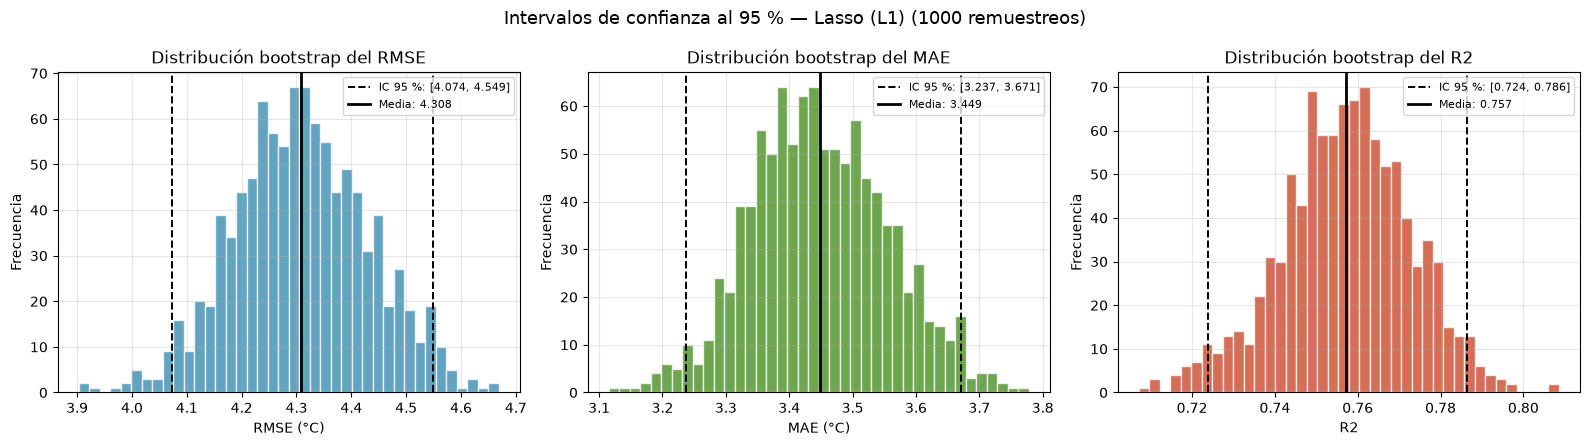

In [73]:
# Distribución bootstrap de cada métrica con su intervalo de confianza al 95 %
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.5))

for eje, metrica, color in zip(ejes, ["RMSE", "MAE", "R2"], ["#2E86AB", "#3E8914", "#C73E1D"]):
    valores = metricas_bootstrap[metrica]
    eje.hist(valores, bins=40, color=color, alpha=0.75, edgecolor="white")
    inferior, superior = valores.quantile(0.025), valores.quantile(0.975)
    eje.axvline(inferior, color="black", linestyle="--", linewidth=1.4, label=f"IC 95 %: [{inferior:.3f}, {superior:.3f}]")
    eje.axvline(superior, color="black", linestyle="--", linewidth=1.4)
    eje.axvline(valores.mean(), color="black", linewidth=2, label=f"Media: {valores.mean():.3f}")
    eje.set_title(f"Distribución bootstrap del {metrica}")
    eje.set_xlabel(metrica + (" (°C)" if metrica != "R2" else ""))
    eje.set_ylabel("Frecuencia")
    eje.legend(fontsize=8)
    eje.grid(alpha=0.3)

plt.suptitle(f"Intervalos de confianza al 95 % — {nombre_mejor} ({n_remuestreos_bootstrap} remuestreos)", fontsize=13)
plt.tight_layout()
plt.show()

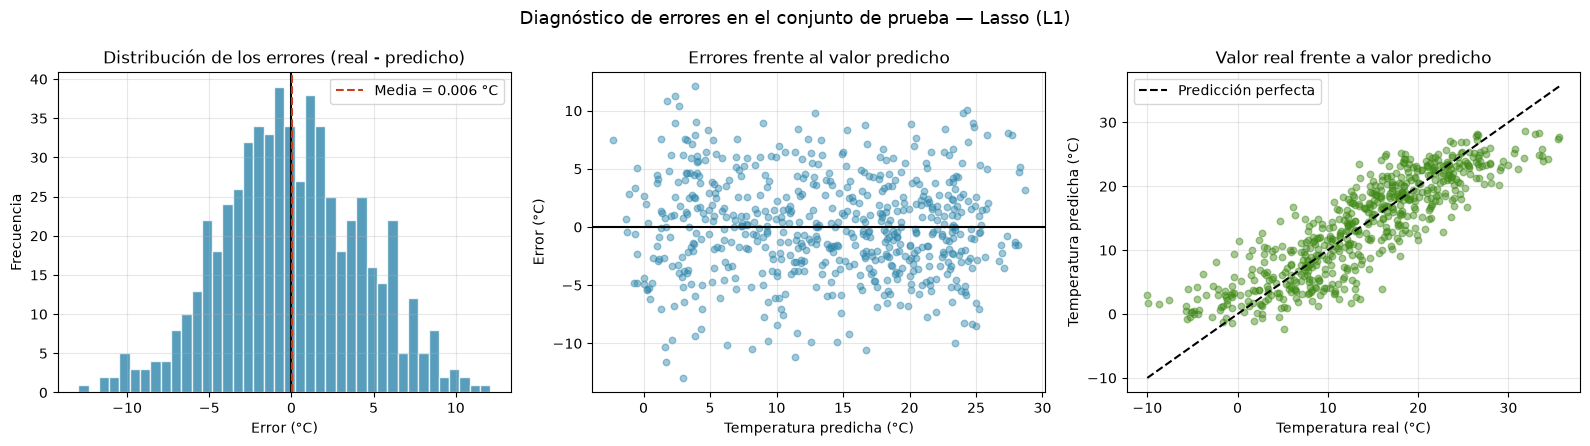

Estadísticas de los errores en el conjunto de prueba:
count   597.0000
mean      0.0060
std       4.3140
min     -12.9710
25%      -2.8650
50%      -0.1720
75%       2.8450
max      12.1010

  Días con error absoluto <= 1 °C: 18.3 %
  Días con error absoluto <= 2 °C: 36.3 %
  Días con error absoluto <= 3 °C: 52.4 %
  Días con error absoluto <= 5 °C: 74.9 %


In [74]:
# Diagnóstico de los errores del modelo sobre el conjunto de prueba
fig, ejes = plt.subplots(1, 3, figsize=(16, 4.5))

ejes[0].hist(residuales, bins=40, color="#2E86AB", alpha=0.8, edgecolor="white")
ejes[0].axvline(0, color="black", linewidth=1.5)
ejes[0].axvline(residuales.mean(), color="#C73E1D", linestyle="--", linewidth=1.5,
                label=f"Media = {residuales.mean():.3f} °C")
ejes[0].set_title("Distribución de los errores (real - predicho)")
ejes[0].set_xlabel("Error (°C)")
ejes[0].set_ylabel("Frecuencia")
ejes[0].legend()
ejes[0].grid(alpha=0.3)

ejes[1].scatter(predicciones_test, residuales, alpha=0.45, s=22, color="#2E86AB")
ejes[1].axhline(0, color="black", linewidth=1.5)
ejes[1].set_title("Errores frente al valor predicho")
ejes[1].set_xlabel("Temperatura predicha (°C)")
ejes[1].set_ylabel("Error (°C)")
ejes[1].grid(alpha=0.3)

limite_min = min(y_test.min(), predicciones_test.min())
limite_max = max(y_test.max(), predicciones_test.max())
ejes[2].scatter(y_test, predicciones_test, alpha=0.45, s=22, color="#3E8914")
ejes[2].plot([limite_min, limite_max], [limite_min, limite_max], "k--", linewidth=1.5,
             label="Predicción perfecta")
ejes[2].set_title("Valor real frente a valor predicho")
ejes[2].set_xlabel("Temperatura real (°C)")
ejes[2].set_ylabel("Temperatura predicha (°C)")
ejes[2].legend()
ejes[2].grid(alpha=0.3)

plt.suptitle(f"Diagnóstico de errores en el conjunto de prueba — {nombre_mejor}", fontsize=13)
plt.tight_layout()
plt.show()

print("Estadísticas de los errores en el conjunto de prueba:")
print(pd.Series(residuales).describe().round(3).to_string())
print()
for umbral in [1, 2, 3, 5]:
    porcentaje = 100 * np.mean(np.abs(residuales) <= umbral)
    print(f"  Días con error absoluto <= {umbral} °C: {porcentaje:.1f} %")

### Comparación de los intervalos de confianza entre modelos

Para complementar el análisis, aplicamos el mismo procedimiento de *bootstrapping* a todos los modelos. Esto permite responder una pregunta más útil para la decisión de negocio que la simple comparación de valores puntuales: **¿las diferencias de desempeño entre modelos son mayores que la incertidumbre de la propia medición?** Si los intervalos de confianza se solapan ampliamente, afirmar que un modelo es "mejor" que otro carece de sustento estadístico.

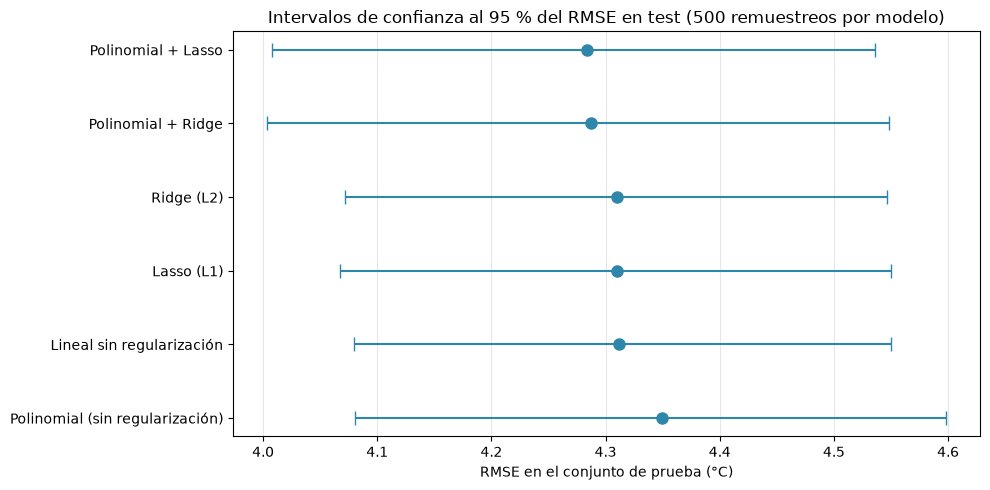

,RMSE_test,IC inferior,IC superior,Amplitud
Modelo,,,,
Polinomial + Lasso,4.2835,4.0080,4.5361,0.5280
Polinomial + Ridge,4.2869,4.0033,4.5482,0.5449
Ridge (L2),4.3100,4.0721,4.5469,0.4748
Lasso (L1),4.3102,4.0674,4.5496,0.4823
Lineal sin regularización,4.3116,4.0798,4.5496,0.4699
Polinomial (sin regularización),4.3498,4.0803,4.5982,0.5179


In [75]:
intervalos_por_modelo = []
for nombre, busqueda in busquedas.items():
    reducido = "Polinomial" in nombre and "Lineal" not in nombre
    prediccion = busqueda.best_estimator_.predict(X_test_reducido if reducido else X_test_completo)

    generador_comparacion = np.random.default_rng(RANDOM_STATE)
    rmse_remuestreos = []
    for _ in range(500):
        muestra = generador_comparacion.choice(indices_test, size=len(indices_test), replace=True)
        rmse_remuestreos.append(root_mean_squared_error(y_test.values[muestra], prediccion[muestra]))

    rmse_remuestreos = np.array(rmse_remuestreos)
    intervalos_por_modelo.append({
        "Modelo": nombre,
        "RMSE_test": root_mean_squared_error(y_test, prediccion),
        "IC inferior": np.percentile(rmse_remuestreos, 2.5),
        "IC superior": np.percentile(rmse_remuestreos, 97.5),
    })

intervalos_por_modelo = pd.DataFrame(intervalos_por_modelo).set_index("Modelo").sort_values("RMSE_test")
intervalos_por_modelo["Amplitud"] = intervalos_por_modelo["IC superior"] - intervalos_por_modelo["IC inferior"]

fig, eje = plt.subplots(figsize=(10, 5))
posiciones = np.arange(len(intervalos_por_modelo))
eje.errorbar(
    intervalos_por_modelo["RMSE_test"], posiciones,
    xerr=[
        intervalos_por_modelo["RMSE_test"] - intervalos_por_modelo["IC inferior"],
        intervalos_por_modelo["IC superior"] - intervalos_por_modelo["RMSE_test"],
    ],
    fmt="o", color="#2E86AB", capsize=5, markersize=8,
)
eje.set_yticks(posiciones)
eje.set_yticklabels(intervalos_por_modelo.index)
eje.invert_yaxis()
eje.set_xlabel("RMSE en el conjunto de prueba (°C)")
eje.set_title("Intervalos de confianza al 95 % del RMSE en test (500 remuestreos por modelo)")
eje.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()

intervalos_por_modelo.round(4)

## 7. Análisis de resultados

Esta sección responde las preguntas planteadas en el enunciado a partir de la evidencia numérica producida en las actividades anteriores. Todos los valores citados provienen de las celdas ejecutadas arriba.

### Resumen de lo obtenido

| Modelo | Hiperparámetros | RMSE (CV) | Desv. est. (CV) | RMSE (test) | R² (test) |
|:---|:---|---:|---:|---:|---:|
| **Lasso (L1)** | MinMax, α = 0,0121 | **4,3146** | 0,0979 | 4,3102 | 0,7581 |
| Polinomial + Ridge | MinMax, grado 4, α = 1,0 | 4,3512 | **0,0896** | 4,2869 | 0,7607 |
| Ridge (L2) | MinMax, α = 3,1623 | 4,3557 | 0,1448 | 4,3100 | 0,7581 |
| Polinomial + Lasso | Standard, grado 4, α = 0,01 | 4,3628 | 0,0904 | **4,2835** | **0,7611** |
| Polinomial (sin reg.) | MinMax, grado 2 | 4,3921 | 0,1135 | 4,3498 | 0,7536 |
| Lineal sin regularización | StandardScaler | 4,4065 | 0,2324 | 4,3116 | 0,7579 |

El hallazgo más importante para leer todo lo que sigue es que **los seis modelos están contenidos en un rango de 0,09 °C de RMSE**, mientras que el intervalo de confianza al 95 % del RMSE de cualquiera de ellos tiene una amplitud de aproximadamente **0,48 °C**. Es decir: la diferencia entre el mejor y el peor modelo es cinco veces menor que la incertidumbre con la que medimos a cada uno.

In [76]:
# Referencia de negocio: ¿cuánto mejora el modelo frente a "predecir siempre el promedio"?
prediccion_ingenua = np.full(len(y_test), y_train.mean())
rmse_ingenuo = root_mean_squared_error(y_test, prediccion_ingenua)
mae_ingenuo = mean_absolute_error(y_test, prediccion_ingenua)
rmse_modelo = root_mean_squared_error(y_test, predicciones_test)

print(f"Modelo trivial (predecir siempre {y_train.mean():.2f} °C):")
print(f"   RMSE = {rmse_ingenuo:.4f} °C   MAE = {mae_ingenuo:.4f} °C")
print(f"Modelo seleccionado ({nombre_mejor}):")
print(f"   RMSE = {rmse_modelo:.4f} °C   MAE = {mean_absolute_error(y_test, predicciones_test):.4f} °C")
print()
print(f"Reducción del error frente al modelo trivial: {100 * (1 - rmse_modelo / rmse_ingenuo):.1f} %")

Modelo trivial (predecir siempre 13.72 °C):
   RMSE = 8.7633 °C   MAE = 7.1602 °C
Modelo seleccionado (Lasso (L1)):
   RMSE = 4.3102 °C   MAE = 3.4489 °C

Reducción del error frente al modelo trivial: 50.8 %


### 7.1 Análisis cuantitativo

**¿Cuál modelo obtuvo el mejor desempeño en el conjunto de test?**

El mejor RMSE en test lo obtuvo **Polinomial + Lasso** (4,2835 °C; R² = 0,7611), seguido muy de cerca por Polinomial + Ridge (4,2869 °C). Los cuatro modelos restantes quedan entre 4,3100 y 4,3498 °C. La distancia entre el primero y el cuarto es de 0,027 °C, es decir, **menos de tres centésimas de grado**: en términos prácticos, los modelos son indistinguibles en test.

**¿Coincide el mejor desempeño en test con el mejor promedio en validación cruzada? Si no coincide, ¿cuál puede ser la explicación?**

**No coincide.** En validación cruzada el mejor fue **Lasso (L1)** con 4,3146 °C, mientras que Polinomial + Lasso quedó en cuarto lugar (4,3628 °C); en test el orden se invierte. Hay tres razones que explican esto y ninguna implica que algo esté mal:

1. **Las diferencias son menores que el ruido de medición.** La separación entre el primero y el cuarto puesto en CV es de 0,048 °C, mientras que la desviación estándar del RMSE entre los cinco *folds* es de 0,09 a 0,23 °C. Cuando la diferencia entre dos candidatos es más pequeña que la variabilidad con la que se mide a cada uno, el orden entre ellos es esencialmente aleatorio.
2. **Se están midiendo cosas distintas.** El RMSE de CV es el promedio de cinco evaluaciones sobre ≈358 días cada una, con modelos entrenados sobre el 80 % de los datos. El RMSE de test es **una sola** evaluación sobre 597 días con el modelo entrenado sobre el 100 % del conjunto de entrenamiento. Son dos estimadores diferentes del mismo desempeño esperado.
3. **El conjunto de test resultó ligeramente "más fácil".** La columna `Diferencia CV vs test` es negativa para los seis modelos (entre −0,004 y −0,095 °C): todos rinden algo mejor en test que en validación. Un desplazamiento sistemático en la misma dirección para todos los modelos es característica de la partición, no de los modelos.

La conclusión metodológica es la correcta: **la selección debe hacerse con validación cruzada, no con el conjunto de test**. Si eligiéramos el modelo por su desempeño en test, estaríamos usando el conjunto de evaluación para tomar una decisión y ya no tendríamos ninguna estimación honesta del desempeño futuro.

**¿El modelo con mejor métrica promedio es necesariamente el más adecuado? Justifique considerando también la desviación estándar.**

No necesariamente, y este conjunto de resultados lo ilustra bien. El caso más claro es el de la **regresión lineal sin regularización**: su RMSE promedio (4,4065 °C) es el peor de los seis, pero además su desviación estándar entre *folds* (0,2324 °C) es **2,4 veces mayor** que la del mejor modelo. Es decir, no solo es peor en promedio: su desempeño depende mucho más de qué datos concretos le toquen. En producción eso se traduce en periodos en los que el error sería notablemente mayor que el anunciado.

Comparando los dos primeros: Lasso tiene mejor promedio (4,3146 frente a 4,3512) pero Polinomial + Ridge es ligeramente más estable (0,0896 frente a 0,0979). La diferencia de promedios (0,037 °C) es **menor que cualquiera de las dos desviaciones estándar**, de modo que estadísticamente están empatados. Cuando dos modelos empatan en desempeño y en estabilidad, el criterio de desempate debe ser otro: **la complejidad**. Y ahí la diferencia sí es grande: Lasso es un modelo lineal con 31 coeficientes (18 no nulos), mientras que Polinomial + Ridge necesita 494 columnas polinomiales de grado 4 que no admiten interpretación directa.

**Con base en las curvas de validación, ¿cómo cambia el error a medida que aumenta la complejidad? ¿En qué punto se evidencia sobreajuste?**

La curva de validación de la Actividad 2 muestra el comportamiento de manual del compromiso sesgo-varianza:

| Grado | Columnas | RMSE entrenamiento | RMSE validación | Desv. est. (val) | Brecha |
|---:|---:|---:|---:|---:|---:|
| 1 | 8 | 4,4737 | 4,5011 | 0,0949 | 0,027 |
| 2 | 44 | 4,2628 | **4,3921** | 0,1135 | 0,129 |
| 3 | 164 | 4,0006 | 4,5310 | 0,1136 | 0,531 |
| 4 | 494 | 3,5206 | 7,0864 | 1,2424 | 3,566 |
| 5 | 1.286 | 2,6486 | 40,1180 | 25,3859 | 37,469 |

- **El error de entrenamiento decrece de forma monótona** (4,47 → 2,65 °C). Esto es esperable y por sí solo no dice nada: un modelo más flexible siempre puede ajustar mejor los datos que ya vio.
- **El error de validación tiene forma de U** con mínimo en el **grado 2** (4,3921 °C). El grado 1 se queda corto (sesgo: no captura la relación no lineal entre humedad, estacionalidad y temperatura) y a partir del grado 3 empieza a empeorar.
- **El sobreajuste se evidencia desde el grado 3** —donde la brecha entre validación y entrenamiento se cuadruplica (de 0,13 a 0,53 °C) aunque el error de validación todavía es razonable— y se vuelve **catastrófico a partir del grado 4**, cuando el modelo dispone de 494 columnas para 1.432 filas de entrenamiento por *fold*. En el grado 5 (1.286 columnas frente a 1.432 filas) el R² de validación llega a **−26,55**: el modelo predice peor que decir siempre el promedio.
- **La varianza confirma el diagnóstico.** La desviación estándar entre *folds* pasa de 0,09 °C en el grado 1 a **25,39 °C** en el grado 5. Un modelo cuyo error cambia en decenas de grados según qué datos le toquen no es utilizable: no es solo que se equivoque más, es que es imposible anticipar cuánto se equivocará.

**¿Cómo afecta la regularización la magnitud y estabilidad de los coeficientes?**

Bajo el escalador común (`StandardScaler` en los tres modelos, con los `alpha` seleccionados):

| | Suma de \|coeficientes\| | Coeficiente máximo | Coeficientes en cero |
|:---|---:|---:|---:|
| Sin regularización | 27,29 | 5,95 | 0 de 31 |
| Ridge (α = 3,16) | 26,73 | 5,90 | 0 de 31 |
| Lasso (α = 0,0121) | 23,62 | 6,05 | **7 de 31** |

Sobre la **magnitud**: la regularización sí encoge los coeficientes, pero de forma **moderada** (−2 % con Ridge, −13 % con Lasso). En cuanto a la **estabilidad**, la desviación promedio de los coeficientes a lo largo de 40 remuestreos *bootstrap* es 0,2968 (sin regularización), 0,3034 (Ridge) y 0,2937 (Lasso): **prácticamente idéntica**.

Este resultado, que a primera vista parece contradecir la teoría, tiene una explicación clara y es uno de los aprendizajes más valiosos del laboratorio: **la regularización solo tiene mucho que corregir cuando hay mucha varianza que corregir**. Aquí el modelo lineal tiene 31 columnas para 1.791 filas de entrenamiento (una razón de 58 filas por parámetro), de modo que la estimación por mínimos cuadrados ya es de por sí estable. Por eso la búsqueda seleccionó valores de `alpha` pequeños y por eso el efecto es marginal.

La situación cambia por completo en el escenario polinomial, donde sí hay varianza que controlar. Comparando el mejor RMSE de validación alcanzable en cada grado:

| Grado | Sin regularización | + Ridge | + Lasso |
|---:|---:|---:|---:|
| 1 | 4,5011 | 4,5003 | 4,4972 |
| 2 | 4,3921 | 4,3768 | 4,3869 |
| 3 | 4,5310 | 4,3644 | 4,3629 |
| 4 | 7,0864 | 4,3512 | 4,3628 |
| 5 | 40,1180 | 4,3612 | 4,3740 |

En el grado 5 la regularización reduce el RMSE de validación de **40,12 a 4,36 °C**. La curva del modelo sin penalización se dispara; las de Ridge y Lasso se mantienen planas. Esta es la respuesta empírica a la pregunta de la Actividad 4: **sí, la regularización permite aumentar la complejidad sin caer en sobreajuste** — aunque, como muestra la misma tabla, esa complejidad adicional tampoco aporta nada (el mejor valor con regularización, 4,3512, apenas mejora el 4,3921 del grado 2 sin penalización).

**¿Los intervalos de confianza obtenidos mediante *bootstrapping* sugieren estabilidad o alta variabilidad? ¿Qué implicaciones tiene?**

Los intervalos al 95 % del modelo seleccionado (Lasso, 1.000 remuestreos sobre los 597 días de test) son:

| Métrica | Estimación puntual | IC 95 % | Amplitud | Amplitud relativa |
|:---|---:|:---:|---:|---:|
| RMSE | 4,3102 °C | [4,0737 ; 4,5486] | 0,4749 °C | 11,0 % |
| MAE | 3,4489 °C | [3,2370 ; 3,6708] | 0,4338 °C | 12,6 % |
| R² | 0,7581 | [0,7238 ; 0,7864] | 0,0626 | 8,3 % |

La lectura tiene dos caras:

- **El modelo es estable.** Las tres distribuciones *bootstrap* son aproximadamente simétricas y concentradas, sin colas largas ni bimodalidad. Una amplitud del 11 % sobre el RMSE es un resultado razonable para una muestra de 597 observaciones. Además, la media *bootstrap* (4,3085) coincide prácticamente con la estimación puntual (4,3102), lo que indica que no hay sesgo apreciable en la estimación.
- **Pero la incertidumbre es mayor que las diferencias que estábamos discutiendo.** El intervalo abarca ±0,24 °C alrededor del RMSE, mientras que las diferencias entre los seis modelos no llegan a 0,09 °C. La gráfica de intervalos por modelo lo muestra sin ambigüedad: **los seis intervalos se solapan casi por completo** (todos entre ≈4,00 y ≈4,60).

La implicación práctica es doble. Primero, **es incorrecto afirmar que un modelo es mejor que otro con esta evidencia**: la elección entre ellos debe basarse en criterios distintos del desempeño (interpretabilidad, costo, estabilidad), porque en desempeño son estadísticamente equivalentes. Segundo, al reportar el desempeño a AlpesPlanck, el número honesto no es "4,31 °C" sino **"entre 4,07 y 4,55 °C con 95 % de confianza"**; comunicar solo la estimación puntual transmitiría una falsa precisión.

### 7.2 Análisis cualitativo

**¿Qué variables fueron seleccionadas como más relevantes por el modelo Lasso?**

El modelo Lasso seleccionado (con `MinMaxScaler`) anula **13 de 31 coeficientes** y conserva 18. Las variables retenidas, en orden de importancia:

| Variable | Coeficiente | Interpretación |
|:---|---:|:---|
| `dia_cos` | −16,94 | Estacionalidad; es, por mucho, el predictor dominante |
| `humedad_media` | −6,13 | A mayor humedad, menor temperatura máxima |
| `dia_sin` | −5,04 | Segundo componente de la estacionalidad (desfase del ciclo) |
| `humedad_desv` | +4,08 | Días con humedad variable tienden a ser más cálidos |
| `presion_media` | +2,97 | Alta presión asociada a cielos despejados y más calor |
| `sector_viento_*`, `estacion_anio_*` | −2,15 a +1,52 | Ajustes por dirección del viento y estación |
| `rafaga_media`, `viento_max`, `humedad_max` | −0,82 a +0,17 | Aporte marginal |

Y descarta por completo: `presion_min`, `presion_max`, `presion_desv`, `humedad_min`, `viento_media`, `viento_min`, `viento_desv`, `rafaga_min`, `rafaga_max`, `rafaga_desv`, `direccion_viento`, `estacion_anio_primavera` y `sector_viento_SE`.

Lo interesante no es la lista en sí, sino **el patrón**: Lasso está eliminando **redundancia**, no información. De las tres variables de presión conserva únicamente `presion_media`; de las cuatro de humedad conserva `humedad_media`, `humedad_desv` y `humedad_max` y descarta `humedad_min`; de las ocho de viento y ráfaga conserva solo dos. Y descarta `direccion_viento` porque `sector_viento` ya codifica esa misma información en forma categórica. Es exactamente el comportamiento esperado de una penalización L1 ante grupos de variables correlacionadas: **elige un representante del grupo y anula el resto**.

Una advertencia importante que se desprende del experimento con escalador común: con `StandardScaler` Lasso anula **7** variables en lugar de 13, y no exactamente las mismas. Es decir, **la lista de variables "seleccionadas" no es una propiedad objetiva de los datos**, sino el resultado conjunto del método, del valor de `alpha` y de la escala de entrada. Debe presentarse como una guía de relevancia, no como una verdad sobre qué variables importan.

**¿Qué interpretación práctica tienen los coeficientes del modelo final?**

Como el modelo final usa `MinMaxScaler`, cada coeficiente se lee así: **cuánto cambia la temperatura máxima predicha cuando esa variable pasa de su valor mínimo a su valor máximo observado**. Con esa clave:

- `dia_cos = −16,94`: la estacionalidad explica un rango de casi **17 °C** entre el punto más frío y el más cálido del año. Ninguna otra variable se le acerca. En términos del negocio: *la fecha es el predictor más poderoso de la temperatura de mañana*, y todo lo demás son correcciones sobre esa base estacional.
- `humedad_media = −6,13`: pasar del día más seco al más húmedo del registro reduce la temperatura máxima esperada en unos 6 °C. Es coherente con la física: la humedad alta suele venir acompañada de nubosidad, que limita el calentamiento diurno.
- `presion_media = +2,97`: la alta presión (anticiclón, cielo despejado) añade unos 3 °C. También físicamente coherente.
- Los coeficientes de `sector_viento` (entre −2,15 y +1,52) indican que la dirección del viento modula la temperatura en un rango de unos 3,7 °C entre el sector más frío (`N`) y el más cálido (`S`), lo cual es consistente con la circulación esperada en el hemisferio norte.

Que los signos y las magnitudes sean físicamente interpretables es una señal de que el modelo aprendió relaciones reales y no artefactos de los datos.

**¿Existen diferencias relevantes entre el modelo más preciso y el más interpretable?**

En desempeño, **no**. El más preciso en test (Polinomial + Lasso, grado 4, 494 columnas) obtiene 4,2835 °C frente a los 4,3102 °C del más interpretable (Lasso lineal). La diferencia es de **0,027 °C, un 0,6 %**, muy por debajo de la amplitud del intervalo de confianza (0,48 °C).

En todo lo demás, las diferencias sí son relevantes: el modelo polinomial de grado 4 combina 8 variables en 494 términos de interacción y potencias cuyos coeficientes no admiten lectura física; no permite responder preguntas como "¿cuánto influye la humedad?"; es más costoso de calcular y de mantener; y, según la curva de validación, opera en una zona donde el desempeño es muy sensible al valor de `alpha`. **Se paga complejidad e ilegibilidad a cambio de una mejora que no es estadísticamente distinguible de cero.**

**¿Qué decisiones estratégicas podría tomar AlpesPlanck a partir de estos resultados?**

1. **Poner en producción el modelo lineal regularizado (Lasso), no el polinomial.** El desempeño es equivalente y el modelo es auditable, explicable a un cliente y barato de mantener.
2. **Dejar de invertir en complejidad del modelo e invertir en datos.** La evidencia es contundente: seis familias de modelos, con búsquedas sobre grado, escalamiento y penalización, convergen todas al mismo techo de ≈4,3 °C. Ese techo no lo impone el algoritmo, lo imponen las variables disponibles. Ganancias reales requerirían **nuevas variables** (temperatura del día actual —que llamativamente no está en el conjunto—, nubosidad, precipitación, datos de estaciones vecinas, salidas de modelos numéricos de pronóstico).
3. **Comunicar el desempeño con su incertidumbre.** El compromiso con el cliente debe ser "error típico entre 4,07 y 4,55 °C", no "4,31 °C".
4. **Calibrar las expectativas del servicio con la distribución del error, no con el promedio.** Solo el **18,3 %** de los días tiene un error menor a 1 °C, el 52,4 % menor a 3 °C y el **25,1 % supera los 5 °C**. Si el caso de uso requiere precisión de ±2 °C, este modelo solo la cumple en el 36 % de los días: hay que decirlo antes de comprometer el servicio.
5. **Usar el modelo como línea base, no como producto final.** Un RMSE de 4,31 °C frente a los 8,77 °C del modelo trivial (predecir siempre el promedio) es una mejora del 51 %: valioso como punto de partida, insuficiente para competir con un pronóstico meteorológico profesional.

**¿Mayor precisión implica necesariamente mayor valor para la organización?**

No. Este laboratorio es un buen contraejemplo: pasar del modelo lineal al polinomial de grado 4 mejora el RMSE en 0,027 °C —una diferencia que ni siquiera se puede distinguir del ruido— a cambio de perder toda la interpretabilidad. El valor de una mejora depende de si **cambia alguna decisión**. Una reducción del error que no modifica ninguna acción del negocio tiene valor cero, por más que mejore la métrica. En cambio, poder explicarle a un cliente *por qué* el modelo pronostica 22 °C sí cambia decisiones: genera confianza, permite detectar cuándo el modelo va a fallar y facilita la aprobación regulatoria o comercial.

**¿Un modelo más complejo necesariamente genera mayor valor empresarial?**

No, y conviene desglosarlo en las tres dimensiones que plantea la pregunta:

- **Interpretabilidad:** el modelo lineal permite decir "la humedad alta baja la temperatura esperada unos 6 °C"; el polinomial de grado 4 no permite ninguna afirmación de ese tipo. Para un cliente que necesita entender el pronóstico, esa diferencia es sustancial.
- **Estabilidad:** la curva de validación muestra que al aumentar el grado el desempeño se vuelve dramáticamente más sensible a los datos (desviación entre *folds* de 0,09 a 25,39 °C). Un modelo complejo mal regularizado es un riesgo operativo: puede degradarse de forma abrupta cuando los datos cambien.
- **Costo de implementación:** 494 columnas polinomiales implican más cómputo en cada predicción, más memoria, un pipeline más frágil y mayor dificultad para diagnosticar fallas en producción.

La conclusión es el principio de parsimonia: **ante desempeños equivalentes, el modelo más simple es estrictamente superior**, porque cuesta menos y se entiende más.

### 7.3 Reflexión conceptual

**¿Qué relación observas entre complejidad del modelo, capacidad de generalización y estabilidad del desempeño?**

Los resultados dibujan las tres curvas clásicas de forma muy nítida:

- **Complejidad y ajuste a los datos vistos:** relación monótona. El RMSE de entrenamiento baja siempre (4,47 → 2,65 °C del grado 1 al 5). Por eso el error de entrenamiento nunca sirve para elegir un modelo.
- **Complejidad y generalización:** relación en forma de U. El error de validación mejora del grado 1 al 2 (se reduce el sesgo) y empeora del 3 en adelante (crece la varianza). El óptimo está en el punto donde el modelo es lo bastante flexible para capturar la señal y no tanto como para capturar el ruido.
- **Complejidad y estabilidad:** relación monótona creciente, y **más rápida que la del error promedio**. Este es el hallazgo más interesante: entre el grado 3 y el 4 el RMSE promedio se multiplica por 1,6, pero su desviación estándar se multiplica por **11**. La inestabilidad aparece antes y crece más rápido que el error promedio, lo que significa que **la desviación estándar es un detector de sobreajuste más sensible que la media** y debería mirarse siempre.

Los tres fenómenos comparten un mismo origen: la razón entre número de parámetros y número de observaciones. Mientras hay muchas más filas que columnas, el modelo estima sus coeficientes con precisión; cuando esa razón se acerca a uno, cada coeficiente se estima con muy poca información efectiva, se vuelve muy sensible a la muestra concreta, y el modelo empieza a memorizar en lugar de generalizar.

**¿Qué fuentes de sesgo podrían estar presentes en los datos o en el proceso de modelado?**

*Del proceso de modelado (introducidas por nuestras decisiones):*

1. **Validación cruzada aleatoria sobre datos temporales.** Usamos `KFold(shuffle=True)`, de modo que días consecutivos —fuertemente correlacionados entre sí— pueden quedar repartidos entre entrenamiento y validación. Esto hace que **las métricas reportadas sean probablemente optimistas** frente al escenario real de producción (predecir el futuro a partir del pasado). Un `TimeSeriesSplit` daría una estimación más conservadora y realista.
2. **Preprocesamiento calculado antes de particionar.** Las medianas de imputación y los límites IQR se calcularon una sola vez sobre todo el conjunto, como se advirtió en la nota metodológica de la Parte I. Es una fuga de información leve, pero real, hacia los *folds* de validación.
3. **Filtro basado en la variable objetivo.** Se eliminaron 5 registros con `temp_max_manana > 35 °C` en meses fríos por considerarse implausibles. Es una decisión de limpieza tomada mirando la etiqueta; afecta al 0,21 % de las filas y su impacto es mínimo, pero conviene declararla.
4. **Una única partición train/test.** Todo el análisis descansa en una sola semilla (`random_state=42`). Como muestran los intervalos *bootstrap*, otra partición podría desplazar los RMSE en ±0,24 °C y, muy probablemente, alterar el ranking entre modelos. Una validación cruzada anidada daría una estimación más robusta.
5. **Selección de las 8 variables por correlación lineal.** Se calculó solo sobre entrenamiento (correcto), pero la correlación de Pearson **solo detecta relaciones lineales**: una variable con una relación fuerte pero no lineal con la temperatura habría quedado excluida del conjunto usado en los modelos polinomiales, justamente donde más falta haría.

*De los datos:*

6. **Cobertura geográfica y temporal limitada.** Una sola ubicación y el periodo 2009–2015. El modelo no generaliza a otras ubicaciones y, ante la tendencia climática, su desempeño podría degradarse con los años.
7. **Datos faltantes no aleatorios.** Cada columna tenía entre 2 % y 4 % de faltantes. Si esos vacíos se concentran en condiciones meteorológicas extremas (fallas del sensor en tormentas, por ejemplo), la imputación por mediana empuja sistemáticamente esos días hacia la normalidad y el modelo aprende un clima más apacible del real.
8. **Resolución de fechas duplicadas por `keep="first"`.** Ante 108 filas con fecha repetida se conservó arbitrariamente la primera. Si la segunda observación fuera sistemáticamente la corregida, estaríamos conservando de forma consistente la versión errónea.

**Si el tamaño de muestra fuera mayor, ¿esperarías cambios en la estabilidad de los modelos?**

Sí, y en tres direcciones distintas:

1. **Menor variabilidad de las métricas.** El error estándar de una métrica decrece aproximadamente con 1/√n. Cuadruplicar el tamaño del conjunto de prueba reduciría a la mitad la amplitud del intervalo de confianza del RMSE (de ≈0,47 a ≈0,24 °C). Esto es importante porque, como vimos, **con la muestra actual no podemos distinguir entre los modelos**: con cuatro veces más datos quizá sí podríamos, y la comparación dejaría de ser un empate.
2. **Desplazamiento del punto de sobreajuste hacia modelos más complejos.** El colapso del grado 4 ocurre porque 494 columnas compiten con 1.432 filas. Con 10.000 filas de entrenamiento, ese mismo grado 4 tendría 20 observaciones por parámetro y probablemente generalizaría bien; el punto de quiebre se movería al grado 5 o 6. Es decir, **la complejidad óptima no es una propiedad del problema, sino del problema y de la cantidad de datos disponibles conjuntamente**.
3. **Menor —no mayor— utilidad de la regularización para el modelo lineal.** Ya observamos que con 1.791 filas y 31 columnas la penalización aporta poco. Con más datos aportaría todavía menos, porque el estimador de mínimos cuadrados es consistente: su varianza tiende a cero conforme crece la muestra. La regularización es una herramienta para el régimen de datos escasos en relación con los parámetros.

Ahora bien, **más datos no arreglarían el techo de ≈4,3 °C**. Ese límite proviene de que las variables disponibles no contienen suficiente información sobre la temperatura del día siguiente, y eso es un problema de *qué* se mide, no de *cuánto*. Más filas reducen la varianza; para reducir el sesgo hacen falta mejores variables.

---

## Conclusión y modelo recomendado

**Modelo seleccionado: regresión lineal con regularización Lasso (L1)**, `MinMaxScaler` y α = 0,0121, entrenado sobre las 21 variables predictoras.

Justificación de la elección, en las tres dimensiones exigidas por el enunciado:

| Criterio | Sustento |
|:---|:---|
| **Desempeño** | Mejor RMSE promedio en validación cruzada (4,3146 °C) entre los seis modelos, y R² de 0,7728. En test confirma 4,3102 °C y R² de 0,7581. |
| **Estabilidad** | Segunda menor desviación estándar entre *folds* (0,0979 °C) y **la menor brecha entre entrenamiento y validación de todos los modelos** (0,0515 °C), lo que indica que casi no sobreajusta. La diferencia entre CV y test es de apenas −0,0044 °C: la validación cruzada predijo su desempeño real con una precisión de cuatro milésimas de grado. |
| **Complejidad** | Modelo lineal con 18 coeficientes no nulos, cada uno interpretable en grados centígrados. Frente a los modelos polinomiales (494 columnas), es más barato, más explicable y más fácil de mantener, sin diferencia estadísticamente distinguible en desempeño. |

**Desempeño esperado en producción:** RMSE de 4,31 °C, con un intervalo de confianza al 95 % de **[4,07 ; 4,55] °C**; MAE de 3,45 °C; R² de 0,76. Aproximadamente la mitad de los días el error será inferior a 3 °C y uno de cada cuatro días superará los 5 °C.

---

## Actividad 7. Guion del video (máximo 3 minutos)

Dirigido al ingeniero de *machine learning* que lidera el equipo de AlpesPlanck.

| Tiempo | Contenido | Mensaje clave |
|:---|:---|:---|
| 0:00 – 0:20 | Punto de partida | Del modelo lineal del Lab 1 pasamos a comparar seis alternativas: polinomial, Ridge, Lasso y polinomial regularizado, todas con búsqueda de hiperparámetros por validación cruzada. |
| 0:20 – 1:00 | Complejidad y sobreajuste | Mostrar la curva de validación. El error de entrenamiento siempre baja; el de validación tiene mínimo en grado 2 y explota en grado 4 (494 columnas para 1.432 filas). La desviación entre *folds* pasa de 0,09 a 25 °C: la inestabilidad avisa antes que el error promedio. |
| 1:00 – 1:40 | Qué aporta la regularización | En el modelo lineal, poco (ya hay 58 filas por parámetro). En el polinomial, es decisiva: en grado 5 el RMSE pasa de 40 a 4,4 °C. Lasso además descarta 13 de 31 coeficientes, eliminando redundancia entre variables de presión, humedad y viento. |
| 1:40 – 2:20 | Modelo recomendado y su incertidumbre | Lasso lineal: RMSE 4,31 °C, IC 95 % [4,07 ; 4,55]. Los seis modelos caen dentro de ese intervalo, así que la decisión se toma por interpretabilidad y costo, no por décimas de grado. |
| 2:20 – 3:00 | Recomendación de negocio | El techo de 4,3 °C lo imponen las variables, no el algoritmo. La siguiente inversión debe ser en datos (temperatura del día actual, nubosidad, estaciones vecinas), no en modelos más complejos. Comunicar siempre el rango, no el punto. |

---

## Uso de herramientas de IA generativa

> **Nota para el equipo:** esta sección debe ser revisada y completada por los integrantes del grupo antes de la entrega. A continuación se declara el uso efectivamente realizado; los apartados de análisis crítico y aportes propios deben reflejar el trabajo y las conclusiones de cada estudiante, tal como exigen los principios del curso (autoría humana, transparencia y pensamiento crítico).

### Declaración del uso

**Herramienta utilizada:** Claude (Anthropic), a través de la interfaz Claude Code.

**Tipo de uso:**

- Generación inicial del esqueleto de código para los pipelines de `scikit-learn`, las mallas de `GridSearchCV`, las curvas de validación y el procedimiento de *bootstrapping*.
- Apoyo en la redacción técnica de las justificaciones metodológicas y del análisis de resultados.
- Explicación conceptual de los efectos de las penalizaciones L1 y L2 y del compromiso sesgo-varianza.
- Depuración de errores de implementación (importaciones faltantes, incompatibilidades de API y errores de codificación de caracteres).

**No se utilizó IAG para:** decidir las métricas de evaluación, definir los conjuntos de variables ni interpretar los resultados finales sin verificación; todas las cifras citadas en el análisis provienen de las celdas ejecutadas en este notebook y fueron contrastadas contra sus salidas.

### Prompts principales

1. *"Implementar un pipeline de regresión polinomial con búsqueda de hiperparámetros (grado y estrategia de escalamiento) mediante GridSearchCV, reportando RMSE, MAE y R² por validación cruzada."*
2. *"Generar curvas de validación que muestren el error de entrenamiento y de validación en función del grado del polinomio, incluyendo su variabilidad entre folds."*
3. *"Construir pipelines con Ridge y Lasso incluyendo alpha y la estrategia de escalamiento como hiperparámetros, y comparar la magnitud y estabilidad de los coeficientes."*
4. *"Implementar bootstrapping sobre el conjunto de test (al menos 500 remuestreos) para estimar intervalos de confianza al 95 % de las métricas de desempeño."*

### Análisis crítico del resultado

**¿Qué errores, imprecisiones o limitaciones se identificaron?**

- La primera versión comparaba la magnitud de los coeficientes de los tres modelos **sin advertir que habían seleccionado escaladores distintos** (`StandardScaler` frente a `MinMaxScaler`). Con esas cifras, la conclusión aparente era que la regularización *aumentaba* los coeficientes, lo cual es falso: el efecto provenía únicamente del cambio de escala de las variables de entrada. Se añadió una comparación controlada con escalador fijo, y solo entonces la lectura resultó válida.
- La malla inicial de hiperparámetros incluía grados hasta 6 para todos los modelos. Al medir el costo real de cada ajuste se comprobó que un solo Lasso de grado 6 tomaba más de 87 segundos, lo que habría hecho la búsqueda inviable. Se acotaron las mallas con un criterio explícito (la razón entre columnas generadas y filas disponibles) en lugar de dejarlas por comodidad.
- La sugerencia inicial de expandir polinómicamente **todas** las variables era inviable: con 21 predictores, el grado 3 genera 2.023 columnas para 1.791 filas. Este cálculo motivó la separación en dos espacios de variables.

**¿Qué conceptos del curso permitieron evaluar o mejorar la respuesta generada?**

El compromiso sesgo-varianza permitió reconocer que la desviación estándar entre *folds* es tan informativa como la media y debía incorporarse tanto a las gráficas como al criterio de selección. El concepto de fuga de información justificó construir el escalamiento dentro del `Pipeline` en lugar de aplicarlo antes de la validación cruzada. Y la noción de que la regularización actúa sobre la varianza del estimador explicó por qué su efecto resultó marginal en el modelo lineal (con 58 observaciones por parámetro) y decisivo en el polinomial.

### Aportes propios del estudiante

*(Completar por el equipo antes de la entrega. Se sugiere explicitar, como mínimo:)*

- Qué decisiones metodológicas fueron discutidas y adoptadas por el grupo (elección de la métrica principal, criterio de selección del modelo final, tratamiento de las variables excluidas).
- Qué ajustes se realizaron sobre el código o las explicaciones generadas inicialmente.
- Qué aprendizajes se obtuvieron del proceso.